In [1]:
# imports
import simpy
import numpy as np
import sys
import pandas as pd
import os
import pickle as pkl
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import matrix_power
from scipy.special import factorial
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import os, sys 
sys.path.append(r'C:\Users\Eshel\workspace\butools2\Python')
sys.path.append(r'C:\Users\Eshel\workspace\one.deep.moment')
sys.path.append(r'C:\Users\Eshel\workspace\non_renewal_queueing_system/code')
from merging import ph_to_map_renewal, create_mom_cor_vector
from utils_sample_ph import * 
from utils import *
import butools 
from butools.ph import *
from scipy.special import factorial
from numpy.linalg import matrix_power
from numpy.linalg import matrix_power
from scipy.stats import rv_discrete
from scipy.special import factorial
is_print = False
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
def ser_moment_n(s, A, mom):
    '''
    ser_moment_n
    :param s:
    :param A:
    :param mom:
    :return:
    '''
    e = np.ones((A.shape[0], 1))
    try:
        mom_val = ((-1) ** mom) * factorial(mom) * np.dot(np.dot(s, matrix_power(A, -mom)), e)
        if mom_val > 0:
            return mom_val
        else:
            return False
    except:
        return False


def compute_first_n_moments(s, A, n=3):
    '''
    compute_first_n_moments
    :param s:
    :param A:
    :param n:
    :return:
    '''
    moment_list = []
    for moment in range(1, n + 1):
        moment_list.append(ser_moment_n(s, A, moment))
    return moment_list


## Defining a new class: of customers
class Customer:
    def __init__(self, p_id, arrival_time, type_cust):
        self.id = p_id
        self.arrival_time = arrival_time
        self.type = type_cust


is_print = False


In [3]:
def ser_moment_n(s, A, mom):
    '''
    ser_moment_n
    :param s:
    :param A:
    :param mom:
    :return:
    '''
    e = np.ones((A.shape[0], 1))
    try:
        mom_val = ((-1) ** mom) * factorial(mom) * np.dot(np.dot(s, matrix_power(A, -mom)), e)
        if mom_val > 0:
            return mom_val
        else:
            return False
    except:
        return False


def compute_first_n_moments(s, A, n=3):
    '''
    compute_first_n_moments
    :param s:
    :param A:
    :param n:
    :return:
    '''
    moment_list = []
    for moment in range(1, n + 1):
        moment_list.append(ser_moment_n(s, A, moment))
    return moment_list


## Defining a new class: of customers
class Customer:
    def __init__(self, p_id, arrival_time, type_cust):
        self.id = p_id
        self.arrival_time = arrival_time
        self.type = type_cust


is_print = False

is_print = False


class Queue_n_streams:

    def __init__(self, arrivals, services, num_arrival_streams, sim_time):

        self.env = simpy.Environment()  # initializing simpy enviroment
        self.server = simpy.Resource(self.env, capacity=1)  # Defining a resource with capacity 1
        self.end_time = sim_time  # The time simulation terminate

        self.id_current = {}  # keeping track of cusotmers id
        # an event can one of three: (1. arrival, 2. entering service 3. service completion)
        self.arrivals = arrivals
        self.services = services
        self.num_arrival_streams = num_arrival_streams
        self.print = False

        self.global_id = 0
        for stream in range(num_arrival_streams):
            self.id_current[stream] = 0

        ### L computation
        self.num_cust_durations = np.zeros(
            500)  ## the time duration of each each state (state= number of cusotmers in the system)
        self.last_event_time = 0  # the time of the last event -
        self.num_cust_sys = 0  # keeping track of number of customers in the system

    def run(self):
        for stream in range(self.num_arrival_streams):
            self.env.process(self.customer_arrivals(stream))  ## Initializing a process
        self.env.run(until=self.end_time)  ## Running the simulaiton until self.end_time

    #########################################################
    ################# Service block #########################
    #########################################################

    def service(self, id_customer):

        arrival_time = self.env.now

        with self.server.request() as req:
            yield req

            yield self.env.timeout(self.services[self.global_id].item())
            self.global_id += 1

            # print('Customer {} complete service at {}'.format(self.global_id, self.env.now))

            ###################################
            ### Tracking number of customers ##
            ###################################

            tot_time = self.env.now - self.last_event_time  # keeping track of the last event
            self.num_cust_durations[
                self.num_cust_sys] += tot_time  # Since the number of customers in the system changes
            # print('Num cust duration', self.num_cust_durations[:5])
            if self.print:
                print(tot_time, self.num_cust_sys)

            # we compute how much time the system had this number of customers
            self.num_cust_sys -= 1  # updating number of cusotmers in the system
            self.last_event_time = self.env.now
            # print('number in the system {} last_event_time {}' .format(self.num_cust_sys , self.last_event_time))

            ###################################
            ###################################
            ###################################

    #########################################################
    ################# Arrival block #########################
    #########################################################

    def customer_arrivals(self, stream_id):

        while True:
            yield self.env.timeout(self.arrivals[stream_id][self.id_current[stream_id]].item())

            self.id_current[stream_id] += 1

            id_customer = self.id_current[stream_id]

            # print('Customer {} arrived at {} from stream {}'.format(id_customer, self.env.now, stream_id))

            ###################################
            ### Tracking number of customers ##
            ###################################

            tot_time = self.env.now - self.last_event_time
            self.num_cust_durations[self.num_cust_sys] += tot_time

            # print('Num cust duration', self.num_cust_durations[:5])

            if self.print:
                print(tot_time, self.num_cust_sys)
            self.num_cust_sys += 1
            self.last_event_time = self.env.now

            # print('number in the system {} last_event_time {}' .format(self.num_cust_sys , self.last_event_time))

            ###################################
            ###################################
            ###################################

            self.env.process(self.service(id_customer))


def estimate_rate(event_times: np.ndarray) -> float:
    event_times = np.asarray(event_times, dtype=float)
    T = event_times[-1] - event_times[0]
    return float((len(event_times) - 1) / T)


def window_count_stats(event_times: np.ndarray, t: float, n_windows: int, rng: np.random.Generator):
    T0, T1 = event_times[0], event_times[-1]
    T = T1 - T0
    starts = T0 + rng.random(n_windows) * (T - t)
    ends = starts + t
    left = np.searchsorted(event_times, starts, side="left")
    right = np.searchsorted(event_times, ends, side="right")
    counts = right - left
    m = float(counts.mean())
    v = float(counts.var(ddof=1)) if n_windows > 1 else 0.0
    return m, v


def estimate_idc_curve(event_times: np.ndarray, t_grid: np.ndarray, n_windows: int, rng: np.random.Generator):
    lam = estimate_rate(event_times)
    idc = np.empty_like(t_grid, dtype=float)
    for k, t in enumerate(t_grid):
        m, v = window_count_stats(event_times, float(t), n_windows, rng)
        idc[k] = v / m if m > 1e-12 else np.nan
    return lam, idc


def idc_superpose(lam1, idc1, lam2, idc2):
    lam = lam1 + lam2
    w1 = lam1 / lam
    return lam, w1 * idc1 + (1.0 - w1) * idc2


def estimate_vN_from_var_slope(t_grid: np.ndarray, varN: np.ndarray, frac_tail: float = 0.4) -> float:
    n = len(t_grid)
    start = int(np.floor((1.0 - frac_tail) * n))
    start = max(0, min(n - 2, start))
    slope, _ = np.polyfit(t_grid[start:], varN[start:], 1)
    return float(slope)


def rbm_mean_wait(lam: float, ES: float, VarS: float, vN: float):
    rho = lam * ES
    if rho >= 1.0:
        raise ValueError(f"Unstable: rho={rho:.4f} >= 1")
    # work-input variance rate
    vX = lam * VarS + (ES ** 2) * vN
    EW = vX / (2.0 * (1.0 - rho))  # mean virtual waiting time / workload
    EL = lam * EW  # Little (mean number in system)
    return rho, vN, vX, EW, EL


def get_nn_model(input_size, output_size, nn_archi):
    if nn_archi == 1:

        class Net(nn.Module):

            def __init__(self, input_size, output_size):
                super().__init__()

                self.fc1 = nn.Linear(input_size, 50)
                self.fc2 = nn.Linear(50, 70)
                self.fc3 = nn.Linear(70, 70)
                self.fc4 = nn.Linear(70, 50)
                self.fc5 = nn.Linear(50, 50)
                self.fc6 = nn.Linear(50, output_size)

            def forward(self, x):
                x = F.relu(self.fc1(x))
                x = F.relu(self.fc2(x))
                x = F.relu(self.fc3(x))
                x = F.relu(self.fc4(x))
                x = F.relu(self.fc5(x))
                x = self.fc6(x)
                return x
    else:

        class Net(nn.Module):

            def __init__(self, input_size, output_size):
                super().__init__()

                self.fc1 = nn.Linear(input_size, 50)
                self.fc2 = nn.Linear(50, 70)
                self.fc3 = nn.Linear(70, 50)
                self.fc4 = nn.Linear(50, 50)
                self.fc5 = nn.Linear(50, output_size)

            def forward(self, x):
                x = F.relu(self.fc1(x))
                x = F.relu(self.fc2(x))
                x = F.relu(self.fc3(x))
                x = F.relu(self.fc4(x))
                x = self.fc5(x)
                return x

    return Net(input_size, output_size)

import numpy as np

# ============================================================
#  A) 4-state MAP generator (Exp-by-state Markov-renewal MAP)
#
#  Family:
#    D0 = -diag(lam_1,...,lam_n)
#    D1 = diag(lam_1,...,lam_n) @ P
#  where P is row-stochastic (post-arrival transition matrix).
#
#  Inter-arrival time conditional on state i is Exp(lam_i).
#  Lag-1 correlation is induced by P.
#
#  Mean is scaled to 1 by multiplying all rates by c = mean.
#  (SCV and rho1 are unchanged by this scaling.)
# ============================================================

def stationary_dist_P(P: np.ndarray) -> np.ndarray:
    """Stationary distribution alpha (row vector entries) for row-stochastic P: alpha = alpha P."""
    n = P.shape[0]
    A = P.T - np.eye(n)
    A[-1, :] = 1.0
    b = np.zeros(n)
    b[-1] = 1.0
    return np.linalg.solve(A, b)

def metrics_exp_by_state_MAP(lams: np.ndarray, P: np.ndarray):
    """
    Closed-form mean, SCV, and lag-1 autocorrelation rho1 for Exp-by-state MAP.
    """
    lams = np.asarray(lams, dtype=float).reshape(-1)
    P = np.asarray(P, dtype=float)
    n = len(lams)
    assert P.shape == (n, n)
    assert np.all(lams > 0)
    assert np.allclose(P.sum(axis=1), 1.0, atol=1e-10)

    alpha = stationary_dist_P(P)  # post-arrival stationary distribution

    m = 1.0 / lams                  # E[T | state=i]
    m2 = 2.0 / (lams ** 2)          # E[T^2 | state=i]

    mean = float(alpha @ m)
    ET2 = float(alpha @ m2)
    var = ET2 - mean * mean
    scv = var / (mean * mean)

    next_mean_given_i = P @ m
    ET1T2 = float(alpha @ (m * next_mean_given_i))
    rho1 = (ET1T2 - mean * mean) / var

    return mean, scv, rho1

def build_exp_by_state_MAP(lams: np.ndarray, P: np.ndarray):
    """Return (D0,D1) for the Exp-by-state MAP."""
    lams = np.asarray(lams, dtype=float).reshape(-1)
    P = np.asarray(P, dtype=float)
    D0 = -np.diag(lams)
    D1 = np.diag(lams) @ P
    return D0, D1

def scale_map_mean_to_1(lams: np.ndarray, P: np.ndarray):
    """Scale all MAP rates so mean inter-arrival time becomes 1."""
    mean, scv, rho1 = metrics_exp_by_state_MAP(lams, P)
    c = mean
    lams2 = lams * c
    mean2, scv2, rho12 = metrics_exp_by_state_MAP(lams2, P)
    # mean2 should be 1 (up to numerical eps)
    return lams2, P, (mean2, scv2, rho12)

def make_grouped_transition_matrix(n=4, s_cross=0.5, stick=0.0, rng=None):
    """
    Create a structured P that can induce negative or positive correlation depending on s_cross / stick.
      - We split states into two groups: fast (0..n/2-1) and slow (n/2..n-1)
      - s_cross controls switching between groups:
           s_cross > 0.5 -> anti-persistent -> tends to negative rho1
           s_cross < 0.5 -> persistent (within group) -> tends to positive rho1
      - stick adds probability of staying in the same state (stronger positive corr)
    """
    if rng is None:
        rng = np.random.default_rng()

    assert n % 2 == 0, "Use even n for the grouped construction."
    g = n // 2
    fast = list(range(g))
    slow = list(range(g, n))

    P = np.zeros((n, n), dtype=float)

    # Distribute probability mass uniformly within destination group
    def uniform_over(indices):
        w = np.zeros(n, dtype=float)
        w[indices] = 1.0 / len(indices)
        return w

    w_fast = uniform_over(fast)
    w_slow = uniform_over(slow)

    for i in range(n):
        # base: mix within group vs across group
        if i in fast:
            base = (1 - s_cross) * w_fast + s_cross * w_slow
        else:
            base = (1 - s_cross) * w_slow + s_cross * w_fast

        # add "stickiness" to same state
        base = (1 - stick) * base
        base[i] += stick

        # tiny jitter to avoid exact symmetry / degeneracy
        base += rng.uniform(0.0, 1e-6, size=n)
        base /= base.sum()
        P[i, :] = base

    return P

def sample_lams_for_scv_range(rng, n=4, scv_target=None):
    """
    Heuristic sampling of rates that tends to produce a broad SCV range.
    If scv_target is given, it biases the disparity accordingly (still approximate).
    """
    # We create 2 fast and 2 slow rates by default (n=4).
    # Larger disparity => larger SCV.
    if n != 4:
        # generic: log-uniform rates
        lams = np.exp(rng.uniform(np.log(0.1), np.log(200.0), size=n))
        return lams

    # Choose a base "fast" scale
    lam_fast = float(np.exp(rng.uniform(np.log(2.0), np.log(200.0))))

    # Choose disparity according to target SCV (rough bias, not exact)
    if scv_target is None:
        ratio = float(np.exp(rng.uniform(np.log(1.0), np.log(2000.0))))
    else:
        # bigger SCV -> bigger ratio
        # map scv_target in [0.1, 8] to ratio range roughly [1, 2000]
        x = (np.clip(scv_target, 0.1, 8.0) - 0.1) / (8.0 - 0.1)
        log_ratio = np.log(1.0) * (1 - x) + np.log(2000.0) * x
        ratio = float(np.exp(rng.uniform(max(np.log(1.0), log_ratio - 1.0),
                                         min(np.log(2000.0), log_ratio + 1.0))))

    lam_slow = lam_fast / ratio

    # add mild variability within fast/slow groups
    lam_fast2 = lam_fast * float(np.exp(rng.uniform(-0.5, 0.5)))
    lam_slow2 = lam_slow * float(np.exp(rng.uniform(-0.5, 0.5)))

    lams = np.array([lam_fast, lam_fast2, lam_slow, lam_slow2], dtype=float)
    lams = np.clip(lams, 1e-6, None)
    return lams

def generate_many_MAPs(
    num_maps=200,
    scv_min=0.1, scv_max=8.0,
    rho_min=-0.2, rho_max=0.2,
    n=4,
    seed=1,
    max_tries=2_000_000,
):
    """
    Rejection-sample a wide range of 4-state MAPs with mean=1, SCV in [scv_min, scv_max],
    and lag-1 autocorrelation in [rho_min, rho_max].

    Returns a list of dicts:
      {"D0":..., "D1":..., "mean":..., "scv":..., "rho1":..., "lams":..., "P":...}
    """
    rng = np.random.default_rng(seed)
    out = []
    tries = 0

    while len(out) < num_maps and tries < max_tries:
        tries += 1

        # sample a target to encourage coverage
        scv_t = float(rng.uniform(scv_min, scv_max))
        rho_t = float(rng.uniform(rho_min, rho_max))

        lams = sample_lams_for_scv_range(rng, n=n, scv_target=scv_t)

        # choose P parameters to steer rho sign/scale
        # s_cross > 0.5 tends negative; < 0.5 tends positive
        s_cross = 0.5 + 0.35 * np.tanh(-5.0 * rho_t)  # heuristic mapping
        s_cross = float(np.clip(s_cross + rng.normal(0, 0.05), 0.0, 1.0))

        # stickiness can boost positive correlation
        stick = float(np.clip(0.6 * max(0.0, rho_t) + rng.uniform(0.0, 0.1), 0.0, 0.85))

        P = make_grouped_transition_matrix(n=n, s_cross=s_cross, stick=stick, rng=rng)

        # scale mean to 1
        lams2, P2, (mean, scv, rho1) = scale_map_mean_to_1(lams, P)

        if (scv_min <= scv <= scv_max) and (rho_min <= rho1 <= rho_max):
            D0, D1 = build_exp_by_state_MAP(lams2, P2)
            out.append({
                "D0": D0,
                "D1": D1,
                "mean": mean,
                "scv": scv,
                "rho1": rho1,
                "lams": lams2,
                "P": P2,
            })

    if len(out) < num_maps:
        print(f"Warning: only generated {len(out)} MAPs in {tries} tries. "
              f"Try increasing max_tries or loosening ranges.")

    return out


# ============================================================
#  B) PH generator with mean=1 and SCV in [0.1, 8]
#
#  For SCV <= 1:
#    Hyper-Erlang mixture of two Erlangs with the SAME mean 1:
#      Erlang(k, rate=k) has mean 1 and SCV = 1/k
#    Mixing two such Erlangs (with same mean) yields SCV that is
#    a convex combination of 1/k1 and 1/k2 (exact control).
#
#  For SCV > 1:
#    2-phase Hyperexponential with equal mixing p=0.5:
#      choose m1, m2 such that:
#         (m1 + m2)/2 = 1
#         SCV = (m1^2 + m2^2) - 1
#      closed-form:
#         m1 = 1 + 0.5*sqrt(2*(SCV-1)),  m2 = 2 - m1
#      rates mu_i = 1/m_i, alpha=[0.5,0.5], T=diag(-mu1,-mu2)
# ============================================================

def ph_mean_scv(alpha, T):
    """Compute mean and SCV of PH(alpha,T) via moments."""
    alpha = np.asarray(alpha, dtype=float).reshape(-1)
    T = np.asarray(T, dtype=float)
    s = T.shape[0]
    e = np.ones(s)

    invT = np.linalg.solve(-T, np.eye(s))
    m1 = float(alpha @ (invT @ e))
    m2 = float(2.0 * alpha @ (invT @ invT @ e))
    var = m2 - m1 * m1
    scv = var / (m1 * m1)
    return m1, scv

def make_ph_hyperexp2_mean1(target_scv):
    """2-phase hyperexponential (p=0.5) with mean=1 and SCV=target_scv (>1)."""
    c2 = float(target_scv)
    assert c2 > 1.0
    d = 0.5 * np.sqrt(2.0 * (c2 - 1.0))
    m1 = 1.0 + d
    m2 = 1.0 - d
    # ensure positive
    m2 = max(m2, 1e-8)

    mu1 = 1.0 / m1
    mu2 = 1.0 / m2

    alpha = np.array([0.5, 0.5], dtype=float)
    T = np.array([[-mu1, 0.0],
                  [0.0, -mu2]], dtype=float)
    return alpha, T

def make_ph_hypererlang_mean1(target_scv, k_max=200):
    """
    Mixture of two Erlangs with mean 1 to match SCV in (0,1].
    Erlang(k, rate=k) has mean 1 and SCV = 1/k.
    We pick k1,k2 such that 1/k brackets target_scv and mix linearly.
    """
    c2 = float(target_scv)
    assert 0.0 < c2 <= 1.0 + 1e-12

    # choose k_low <= 1/c2 <= k_high; then SCV between 1/k_low and 1/k_high
    k_star = 1.0 / c2
    k1 = int(np.floor(k_star))
    k2 = int(np.ceil(k_star))
    k1 = max(1, min(k1, k_max))
    k2 = max(1, min(k2, k_max))

    if k1 == k2:
        # exact Erlang
        k = k1
        # Erlang(k, rate=k): Coxian chain of k phases
        alpha = np.zeros(k)
        alpha[0] = 1.0
        T = np.zeros((k, k))
        for i in range(k):
            T[i, i] = -k
            if i < k - 1:
                T[i, i + 1] = k
        return alpha, T

    scv1 = 1.0 / k1
    scv2 = 1.0 / k2

    # convex combination to match target SCV:
    # c2 = p*scv1 + (1-p)*scv2  => p = (c2 - scv2)/(scv1 - scv2)
    p = (c2 - scv2) / (scv1 - scv2)
    p = float(np.clip(p, 0.0, 1.0))

    # Hyper-Erlang as PH: block-diagonal of two Erlangs
    # Component 1: Erlang(k1, rate=k1)
    # Component 2: Erlang(k2, rate=k2)
    s = k1 + k2
    alpha = np.zeros(s, dtype=float)
    alpha[0] = p
    alpha[k1] = 1.0 - p

    T = np.zeros((s, s), dtype=float)

    # block 1
    for i in range(k1):
        T[i, i] = -k1
        if i < k1 - 1:
            T[i, i + 1] = k1

    # block 2
    off = k1
    for i in range(k2):
        T[off + i, off + i] = -k2
        if i < k2 - 1:
            T[off + i, off + i + 1] = k2

    return alpha, T

def generate_many_PHs(
    num_ph=200,
    scv_min=0.1, scv_max=8.0
):
    """
    Generate PH distributions with mean=1 and SCV in [scv_min, scv_max].
    Returns list of dicts:
      {"alpha":..., "T":..., "mean":..., "scv":...}
    """
    out = []

    for _ in range(num_ph):
        c2 = float(np.random.uniform(scv_min, scv_max))
        if c2 <= 1.0:
            alpha, T = make_ph_hypererlang_mean1(c2)
        else:
            alpha, T = make_ph_hyperexp2_mean1(c2)

        mean, scv = ph_mean_scv(alpha, T)
        out.append({"alpha": alpha, "T": T, "mean": mean, "scv": scv})

    return out

import numpy as np

# ---------------------------
# Moment check (optional)
# ---------------------------
def ph_mean_scv(alpha, T):
    alpha = np.asarray(alpha, float).reshape(-1)
    T = np.asarray(T, float)
    s = T.shape[0]
    e = np.ones(s)

    invT = np.linalg.solve(-T, np.eye(s))
    m1 = float(alpha @ (invT @ e))
    m2 = float(2.0 * alpha @ (invT @ invT @ e))
    var = m2 - m1 * m1
    scv = var / (m1 * m1)
    return m1, scv


# ============================================================
# PH for SCV > 1: 2-phase Hyperexponential with flexible mixing p
#
# Mean constraint:
#   p*m1 + (1-p)*m2 = 1
# Second moment constraint (Exp component i has E[X^2]=2*m_i^2):
#   E[X^2] = 2*(p*m1^2 + (1-p)*m2^2) = 1 + SCV    (since mean=1 => Var=SCV)
#
# Choose p (small p => can reach huge SCV), solve for m1>0 and m2>0.
# ============================================================

def make_ph_hyperexp2_mean1(target_scv, p=None):
    """
    Construct 2-phase hyperexponential PH with mean=1 and SCV=target_scv (>1).
    Returns (alpha, T).
    """
    c2 = float(target_scv)
    if c2 <= 1.0:
        raise ValueError("Hyperexponential is for SCV > 1.")

    # Pick a mixing probability if not provided.
    # For c2 up to 8, p around 0.1-0.3 is typically fine; for larger c2, p smaller helps.
    if p is None:
        # heuristic: p decreases as SCV increases, but keep it away from 0
        p = min(0.45, max(0.02, 1.0 / (c2 + 1.0)))
        # for SCV around 8.7 => p ~ 0.103; for SCV=8 => p~0.111; for SCV=2 => p~0.333

    p = float(p)
    if not (0.0 < p < 1.0):
        raise ValueError("p must be in (0,1).")

    # Let m1 be unknown (mean of Exp component 1), then:
    # m2 = (1 - p*m1)/(1-p)
    # Enforce E[X^2] = 1 + c2:
    # 2*(p*m1^2 + (1-p)*m2^2) = 1 + c2
    #
    # This becomes a quadratic in m1. We'll solve via np.roots.

    # Expand:
    # 2*p*m1^2 + 2*(1 - p*m1)^2/(1-p) = 1 + c2
    A = 2.0 * p + 2.0 * (p**2) / (1.0 - p)
    B = -4.0 * p / (1.0 - p)
    C = 2.0 / (1.0 - p) - (1.0 + c2)

    roots = np.roots([A, B, C])

    candidates = []
    for r in roots:
        if abs(r.imag) < 1e-10:
            m1 = float(r.real)
            if m1 > 0:
                m2 = (1.0 - p * m1) / (1.0 - p)
                if m2 > 0:
                    candidates.append((m1, m2))

    if not candidates:
        raise RuntimeError("Failed to find positive (m1,m2). Try a smaller p (e.g. p=0.05).")

    # Pick a numerically stable candidate (avoid extremely tiny mean unless necessary)
    candidates.sort(key=lambda x: x[0])
    m1, m2 = candidates[0]  # usually gives "smaller m1, larger m2" which creates high SCV

    mu1 = 1.0 / m1
    mu2 = 1.0 / m2

    alpha = np.array([p, 1.0 - p], dtype=float)
    T = np.array([[-mu1, 0.0],
                  [0.0, -mu2]], dtype=float)
    return alpha, T


# ============================================================
# PH for SCV <= 1: Hyper-Erlang mixture with mean=1
# Erlang(k, rate=k): mean 1, SCV=1/k
# Mixture of two such Erlangs (same mean) gives SCV between them.
# ============================================================

def make_ph_hypererlang_mean1(target_scv, k_max=400):
    c2 = float(target_scv)
    if not (0.0 < c2 <= 1.0 + 1e-12):
        raise ValueError("Hyper-Erlang here is for SCV in (0,1].")

    k_star = 1.0 / c2
    k1 = int(np.floor(k_star))
    k2 = int(np.ceil(k_star))
    k1 = max(1, min(k1, k_max))
    k2 = max(1, min(k2, k_max))

    if k1 == k2:
        k = k1
        alpha = np.zeros(k)
        alpha[0] = 1.0
        T = np.zeros((k, k))
        for i in range(k):
            T[i, i] = -k
            if i < k - 1:
                T[i, i + 1] = k
        return alpha, T

    scv1 = 1.0 / k1
    scv2 = 1.0 / k2
    p = (c2 - scv2) / (scv1 - scv2)
    p = float(np.clip(p, 0.0, 1.0))

    s = k1 + k2
    alpha = np.zeros(s, dtype=float)
    alpha[0] = p
    alpha[k1] = 1.0 - p

    T = np.zeros((s, s), dtype=float)

    # Erlang block 1
    for i in range(k1):
        T[i, i] = -k1
        if i < k1 - 1:
            T[i, i + 1] = k1

    # Erlang block 2
    off = k1
    for i in range(k2):
        T[off + i, off + i] = -k2
        if i < k2 - 1:
            T[off + i, off + i + 1] = k2

    return alpha, T


def make_ph_mean1_with_scv(target_scv):
    """
    Unified PH constructor with mean=1 and desired SCV in (0, inf).
    Uses:
      - Hyper-Erlang for SCV <= 1
      - HyperExp-2 (flexible p) for SCV > 1 (can reach SCV >> 3)
    """
    c2 = float(target_scv)
    if c2 <= 1.0:
        return make_ph_hypererlang_mean1(c2)
    else:
        return make_ph_hyperexp2_mean1(c2)



def superpose_map(D0a: np.ndarray, D1a: np.ndarray,
                  D0b: np.ndarray, D1b: np.ndarray,
                  check: bool = True):
    """
    Superposition of two independent MAPs (D0a,D1a) and (D0b,D1b).
    Returns (D0s, D1s) of size (m*n) x (m*n).

    Convention: Q = D0 + D1 is the generator of the background CTMC.
    """
    D0a = np.asarray(D0a, dtype=float)
    D1a = np.asarray(D1a, dtype=float)
    D0b = np.asarray(D0b, dtype=float)
    D1b = np.asarray(D1b, dtype=float)

    if D0a.shape != D1a.shape or D0a.ndim != 2 or D0a.shape[0] != D0a.shape[1]:
        raise ValueError("MAP A: D0a and D1a must be square and same shape.")
    if D0b.shape != D1b.shape or D0b.ndim != 2 or D0b.shape[0] != D0b.shape[1]:
        raise ValueError("MAP B: D0b and D1b must be square and same shape.")

    m = D0a.shape[0]
    n = D0b.shape[0]
    Im = np.eye(m)
    In = np.eye(n)

    D0s = np.kron(D0a, In) + np.kron(Im, D0b)
    D1s = np.kron(D1a, In) + np.kron(Im, D1b)

    if check:
        Qa = D0a + D1a
        Qb = D0b + D1b
        # Basic MAP checks: row sums ~ 0 for Q
        if not np.allclose(Qa.sum(axis=1), 0.0, atol=1e-10):
            raise ValueError("MAP A check failed: rows of (D0a + D1a) must sum to 0.")
        if not np.allclose(Qb.sum(axis=1), 0.0, atol=1e-10):
            raise ValueError("MAP B check failed: rows of (D0b + D1b) must sum to 0.")
        Qs = D0s + D1s
        if not np.allclose(Qs.sum(axis=1), 0.0, atol=1e-10):
            raise ValueError("Superposed MAP check failed: rows of (D0s + D1s) must sum to 0.")

    return D0s, D1s


def superpose_initial(alpha_a: np.ndarray, alpha_b: np.ndarray):
    """
    If you also have initial distributions alpha_a (1xm) and alpha_b (1xn),
    the natural product initial distribution is kron(alpha_a, alpha_b).
    """
    aa = np.asarray(alpha_a, dtype=float).reshape(1, -1)
    ab = np.asarray(alpha_b, dtype=float).reshape(1, -1)
    return np.kron(aa, ab)




def stationary_pi(Q):
    n = Q.shape[0]
    A = Q.T.copy()
    A[-1, :] = 1.0
    b = np.zeros(n)
    b[-1] = 1.0
    return np.linalg.solve(A, b)


def map_mean_scv_rho1(D0, D1):
    n = D0.shape[0]
    Q = D0 + D1
    pi = stationary_pi(Q)

    ones = np.ones(n)
    lam = float(pi @ (D1 @ ones))      # arrival rate
    alpha = (pi @ D1) / lam            # post-arrival state distribution

    M = np.linalg.inv(-D0)

    mean = float(alpha @ (M @ ones))
    m2 = float(2 * alpha @ (M @ M @ ones))
    var = m2 - mean**2
    scv = var / mean**2

    mvec = M @ ones
    ET1T2 = float(alpha @ (M @ M @ (D1 @ mvec)))
    rho1 = (ET1T2 - mean**2) / var

    return mean, scv, rho1


def scale_mean_to_one(D0, D1):
    """
    Scale time so mean interarrival = 1.
    """
    mean, _, _ = map_mean_scv_rho1(D0, D1)
    c = mean  # multiply rates by mean
    return D0 * c, D1 * c


def ser_moment_n(s, A, mom):
    '''
    ser_moment_n
    :param s:
    :param A:
    :param mom:
    :return:
    '''
    e = np.ones((A.shape[0], 1))
    try:
        mom_val = ((-1) ** mom) * factorial(mom) * np.dot(np.dot(s, matrix_power(A, -mom)), e)
        if mom_val > 0:
            return mom_val
        else:
            return False
    except:
        return False


def compute_first_n_moments(s, A, n=3):
    '''
    compute_first_n_moments
    :param s:
    :param A:
    :param n:
    :return:
    '''
    moment_list = []
    for moment in range(1, n + 1):
        moment_list.append(ser_moment_n(s, A, moment))
    return moment_list


## Defining a new class: of customers
class Customer:
    def __init__(self, p_id, arrival_time, type_cust):
        self.id = p_id
        self.arrival_time = arrival_time
        self.type = type_cust


is_print = False

is_print = False


class Queue_n_streams:

    def __init__(self, arrivals, services, num_arrival_streams, sim_time):

        self.env = simpy.Environment()  # initializing simpy enviroment
        self.server = simpy.Resource(self.env, capacity=1)  # Defining a resource with capacity 1
        self.end_time = sim_time  # The time simulation terminate

        self.id_current = {}  # keeping track of cusotmers id
        # an event can one of three: (1. arrival, 2. entering service 3. service completion)
        self.arrivals = arrivals
        self.services = services
        self.num_arrival_streams = num_arrival_streams
        self.print = False

        self.global_id = 0
        for stream in range(num_arrival_streams):
            self.id_current[stream] = 0

        ### L computation
        self.num_cust_durations = np.zeros(
            500)  ## the time duration of each each state (state= number of cusotmers in the system)
        self.last_event_time = 0  # the time of the last event -
        self.num_cust_sys = 0  # keeping track of number of customers in the system

    def run(self):
        for stream in range(self.num_arrival_streams):
            self.env.process(self.customer_arrivals(stream))  ## Initializing a process
        self.env.run(until=self.end_time)  ## Running the simulaiton until self.end_time

    #########################################################
    ################# Service block #########################
    #########################################################

    def service(self, id_customer):

        arrival_time = self.env.now

        with self.server.request() as req:
            yield req

            yield self.env.timeout(self.services[self.global_id].item())
            self.global_id += 1

            # print('Customer {} complete service at {}'.format(self.global_id, self.env.now))

            ###################################
            ### Tracking number of customers ##
            ###################################

            tot_time = self.env.now - self.last_event_time  # keeping track of the last event
            self.num_cust_durations[
                self.num_cust_sys] += tot_time  # Since the number of customers in the system changes
            # print('Num cust duration', self.num_cust_durations[:5])
            if self.print:
                print(tot_time, self.num_cust_sys)

            # we compute how much time the system had this number of customers
            self.num_cust_sys -= 1  # updating number of cusotmers in the system
            self.last_event_time = self.env.now
            # print('number in the system {} last_event_time {}' .format(self.num_cust_sys , self.last_event_time))

            ###################################
            ###################################
            ###################################

    #########################################################
    ################# Arrival block #########################
    #########################################################

    def customer_arrivals(self, stream_id):

        while True:
            yield self.env.timeout(self.arrivals[stream_id][self.id_current[stream_id]].item())

            self.id_current[stream_id] += 1

            id_customer = self.id_current[stream_id]

            # print('Customer {} arrived at {} from stream {}'.format(id_customer, self.env.now, stream_id))

            ###################################
            ### Tracking number of customers ##
            ###################################

            tot_time = self.env.now - self.last_event_time
            self.num_cust_durations[self.num_cust_sys] += tot_time

            # print('Num cust duration', self.num_cust_durations[:5])

            if self.print:
                print(tot_time, self.num_cust_sys)
            self.num_cust_sys += 1
            self.last_event_time = self.env.now

            # print('number in the system {} last_event_time {}' .format(self.num_cust_sys , self.last_event_time))

            ###################################
            ###################################
            ###################################

            self.env.process(self.service(id_customer))


def estimate_rate(event_times: np.ndarray) -> float:
    event_times = np.asarray(event_times, dtype=float)
    T = event_times[-1] - event_times[0]
    return float((len(event_times) - 1) / T)


def window_count_stats(event_times: np.ndarray, t: float, n_windows: int, rng: np.random.Generator):
    T0, T1 = event_times[0], event_times[-1]
    T = T1 - T0
    starts = T0 + rng.random(n_windows) * (T - t)
    ends = starts + t
    left = np.searchsorted(event_times, starts, side="left")
    right = np.searchsorted(event_times, ends, side="right")
    counts = right - left
    m = float(counts.mean())
    v = float(counts.var(ddof=1)) if n_windows > 1 else 0.0
    return m, v


def estimate_idc_curve(event_times: np.ndarray, t_grid: np.ndarray, n_windows: int, rng: np.random.Generator):
    lam = estimate_rate(event_times)
    idc = np.empty_like(t_grid, dtype=float)
    for k, t in enumerate(t_grid):
        m, v = window_count_stats(event_times, float(t), n_windows, rng)
        idc[k] = v / m if m > 1e-12 else np.nan
    return lam, idc


def idc_superpose(lam1, idc1, lam2, idc2):
    lam = lam1 + lam2
    w1 = lam1 / lam
    return lam, w1 * idc1 + (1.0 - w1) * idc2


def estimate_vN_from_var_slope(t_grid: np.ndarray, varN: np.ndarray, frac_tail: float = 0.4) -> float:
    n = len(t_grid)
    start = int(np.floor((1.0 - frac_tail) * n))
    start = max(0, min(n - 2, start))
    slope, _ = np.polyfit(t_grid[start:], varN[start:], 1)
    return float(slope)


def rbm_mean_wait(lam: float, ES: float, VarS: float, vN: float):
    rho = lam * ES
    if rho >= 1.0:
        raise ValueError(f"Unstable: rho={rho:.4f} >= 1")
    # work-input variance rate
    vX = lam * VarS + (ES ** 2) * vN
    EW = vX / (2.0 * (1.0 - rho))  # mean virtual waiting time / workload
    EL = lam * EW  # Little (mean number in system)
    return rho, vN, vX, EW, EL


def get_nn_model(input_size, output_size, nn_archi):
    if nn_archi == 1:

        class Net(nn.Module):

            def __init__(self, input_size, output_size):
                super().__init__()

                self.fc1 = nn.Linear(input_size, 50)
                self.fc2 = nn.Linear(50, 70)
                self.fc3 = nn.Linear(70, 70)
                self.fc4 = nn.Linear(70, 50)
                self.fc5 = nn.Linear(50, 50)
                self.fc6 = nn.Linear(50, output_size)

            def forward(self, x):
                x = F.relu(self.fc1(x))
                x = F.relu(self.fc2(x))
                x = F.relu(self.fc3(x))
                x = F.relu(self.fc4(x))
                x = F.relu(self.fc5(x))
                x = self.fc6(x)
                return x
    else:

        class Net(nn.Module):

            def __init__(self, input_size, output_size):
                super().__init__()

                self.fc1 = nn.Linear(input_size, 50)
                self.fc2 = nn.Linear(50, 70)
                self.fc3 = nn.Linear(70, 50)
                self.fc4 = nn.Linear(50, 50)
                self.fc5 = nn.Linear(50, output_size)

            def forward(self, x):
                x = F.relu(self.fc1(x))
                x = F.relu(self.fc2(x))
                x = F.relu(self.fc3(x))
                x = F.relu(self.fc4(x))
                x = self.fc5(x)
                return x

    return Net(input_size, output_size)


import numpy as np
from numpy.linalg import norm
from scipy.linalg import solve


def stationary_dist_ctmc(Q: np.ndarray) -> np.ndarray:
    """
    Stationary distribution pi (as a row vector entries) of CTMC generator Q:
      pi Q = 0, pi 1 = 1
    Returns pi as a 1D array of length n (interpreted as row).
    """
    n = Q.shape[0]
    A = Q.T.copy()
    A[-1, :] = 1.0
    b = np.zeros(n)
    b[-1] = 1.0
    pi = solve(A, b)
    return pi  # 1D


def map_rate(D0: np.ndarray, D1: np.ndarray) -> float:
    """Arrival rate lambda for MAP(D0,D1)."""
    Q = D0 + D1
    pi = stationary_dist_ctmc(Q)
    ones = np.ones(Q.shape[0])
    return float(pi @ (D1 @ ones))


def ph_mean(alpha: np.ndarray, T: np.ndarray) -> float:
    """Mean of PH(alpha,T). alpha row vector length s."""
    alpha = np.asarray(alpha, dtype=float).reshape(-1)
    ones = np.ones(T.shape[0])
    return float(alpha @ solve(-T, ones))


def compute_R(A_up: np.ndarray, A_same: np.ndarray, A_down: np.ndarray,
              max_iter: int = 20000, tol: float = 1e-12) -> np.ndarray:
    """
    Solve A_up + R A_same + R^2 A_down = 0 for minimal nonnegative R
    via functional iteration:
      R_{k+1} = -A_up (A_same + R_k A_down)^{-1}
    """
    n = A_same.shape[0]
    R = np.zeros((n, n))
    for k in range(max_iter):
        M = A_same + R @ A_down
        R_next = solve(M.T, (-A_up).T).T
        err = norm(R_next - R, ord=np.inf)
        R = R_next
        if err < tol:
            return R
    raise RuntimeError(f"R iteration did not converge in {max_iter} iterations (last err={err})")


def map_ph_1_steady_state_with_marginal(
        D0: np.ndarray, D1: np.ndarray,
        alpha: np.ndarray, T: np.ndarray,
        N_max: int = 200,
        r_tol: float = 1e-12
) -> dict:
    """
    Compute steady state for MAP/PH/1 and return marginal P(N=n) for n=0..N_max.

    Levels:
      - Level 0: MAP background only (size m)
      - Level n>=1: MAP background × PH service phase (size m*s)

    Returns:
      pN: length N_max+1 with P(N=n)
      tail: P(N > N_max)
      plus pi0, pi1, R, rho, etc.
    """
    D0 = np.asarray(D0, dtype=float)
    D1 = np.asarray(D1, dtype=float)
    alpha = np.asarray(alpha, dtype=float).reshape(-1)
    T = np.asarray(T, dtype=float)

    m = D0.shape[0]
    s = T.shape[0]
    ms = m * s

    # --- stability check
    lam = map_rate(D0, D1)
    ES = ph_mean(alpha, T)
    rho = lam * ES
    if rho >= 1.0 - 1e-12:
        raise ValueError(f"Unstable or nearly unstable: rho = {rho} (need < 1).")

    # --- PH completion vector
    ones_s = np.ones(s)
    t = -T @ ones_s  # (s,)

    I_m = np.eye(m)
    I_s = np.eye(s)

    # QBD blocks for levels n>=1 (size ms x ms)
    A_same = np.kron(D0, I_s) + np.kron(I_m, T)
    A_up = np.kron(D1, I_s)
    A_down = np.kron(I_m, np.outer(t, alpha))  # (ms x ms)

    # boundary blocks
    B01 = np.kron(D1, alpha.reshape(1, -1))  # (m x ms)
    B10 = np.kron(I_m, t.reshape(-1, 1))  # (ms x m)

    # --- compute R
    R = compute_R(A_up, A_same, A_down, tol=r_tol)

    # --- solve for pi0 (m) and pi1 (ms)
    M_top = np.hstack([D0.T, B10.T])  # m x (m+ms)
    M_mid = np.hstack([B01.T, (A_same + R @ A_down).T])  # ms x (m+ms)
    M = np.vstack([M_top, M_mid])  # (m+ms) x (m+ms)

    # normalization: pi0*1 + pi1*(I-R)^{-1}*1 = 1
    ones_m = np.ones(m)
    ones_ms = np.ones(ms)
    w = solve(np.eye(ms) - R, ones_ms)  # (I-R)^{-1} 1
    norm_row = np.concatenate([ones_m, w])

    b = np.zeros(m + ms)
    M[-1, :] = norm_row
    b[-1] = 1.0

    u = solve(M, b)
    pi0 = u[:m]
    pi1 = u[m:]

    # --- marginal P(N=n) for n=0..N_max
    pN = np.zeros(N_max + 1, dtype=float)
    pN[0] = float(pi0.sum())

    # iterate pi_n = pi1 R^{n-1} for n>=1
    cur = pi1.copy()
    for n in range(1, N_max + 1):
        pN[n] = float(cur.sum())
        cur = cur @ R

    # --- tail mass P(N > N_max)
    # Total mass at levels >=1 is pi1*(I-R)^{-1}*1
    total_ge1 = float(pi1 @ w)
    mass_1_to_N = float(pN[1:].sum())
    tail = max(0.0, total_ge1 - mass_1_to_N)

    return {
        "rho": rho,
        "lambda": lam,
        "ES": ES,
        "R": R,
        "pi0": pi0,
        "pi1": pi1,
        "pN_0_to_Nmax": pN,  # length N_max+1
        "tail_gt_Nmax": tail,  # P(N > N_max)
        "check_total": float(pN.sum() + tail)  # should be ~1
    }

def choose_scv_larger_3(maps):

    for ind in range(len(maps)):

        ind_rand = np.random.randint(0, len(maps))

        if maps[ind_rand]['scv']>3:
            return ind_rand

    return 0

def choose_scv_lower_3(maps):

    for ind in range(len(maps)):

        ind_rand = np.random.randint(0, len(maps))

        if maps[ind_rand]['scv']<3:
            return ind_rand

    return 0


def choose_scv_larger_3_rho_smaller_0(maps):

    for ind in range(len(maps)):

        ind_rand = np.random.randint(0, len(maps))

        if (maps[ind_rand]['scv']>3)&(maps[ind_rand]['rho1']<0):
            return ind_rand

    return 0


In [4]:
is_print = False

class Queue_n_streams_2_tiers:

    def __init__(self, arrivals, services, num_arrival_streams,sim_time):

        self.env = simpy.Environment() # initializing simpy enviroment 
        
        self.end_time = sim_time # The time simulation terminate
        self.inter_arrivals_c = []
        self.inter_departure =  {}
        self.inter_departure['a'] =  []
        self.inter_departure['b'] =  []
        self.last_depart = {}
        self.last_depart['a'] = 0
        self.last_depart['b'] = 0
        
        self.last_c_arrival = 0
        self.id_current = {} # keeping track of cusotmers id
        #an event can one of three: (1. arrival, 2. entering service 3. service completion)
        self.arrivals = arrivals
        self.services = services
        self.num_arrival_streams = num_arrival_streams
        self.print = False

        for station in ['a', 'b']:
            for stream in range(num_arrival_streams):
                self.id_current[(station,stream)] = 0
        self.id_cust = {}
        for station in ['a', 'b']:
            self.id_cust[station] = 0
        self.sertimesa = []
        ### L computation
        self.num_cust_durations = {} ## the time duration of each each state (state= number of cusotmers in the system)
        self.last_event_time = {} # the time of the last event - 
        self.num_cust_sys = {} #
        self.global_id = {}
        self.server = {}
        for station in ['a', 'b', 'c']:
            self.server[station] = simpy.Resource(self.env, capacity=1) # Defining a resource with capacity 1
            self.num_cust_durations[station] = np.zeros(500) ## the time duration of each each state (state= number of cusotmers in the system)
            self.last_event_time[station] = 0 # the time of the last event - 
            self.num_cust_sys[station] = 0 # keeping track of number of customers in the system
            self.global_id[station] = 0 

    def run(self):
        for station in ['a', 'b']:
            for stream in range(self.num_arrival_streams):
                self.env.process(self.customer_arrivals(station, stream)) ## Initializing a process
        self.env.run(until=self.end_time) ## Running the simulaiton until self.end_time

    
    
    #########################################################
    ################# Service block ######################### 
    ######################################################### 
    
    
    def service(self, id_customer,stream,  station):

        if station == 'c':
            self.inter_arrivals_c.append(self.env.now - self.last_c_arrival)
            self.last_c_arrival = self.env.now
        
        arrival_time = self.env.now
        
        with self.server[station].request() as req:
                       
            yield req
            
            ser_time = self.services[station][self.global_id[station]].item()
            # if station == 'a':
            #     self.sertimesa.append(ser_time)
            yield self.env.timeout(ser_time)
            self.global_id[station] += 1
            
                
            ###################################
            ### Tracking number of customers ##
            ###################################
            # if self.num_cust_sys[station]> 100:
            #     print(station, self.num_cust_sys[station])
            
            tot_time = self.env.now - self.last_event_time[station]  # keeping track of the last event
            self.num_cust_durations[station][self.num_cust_sys[station]] += tot_time # Since the number of customers in the system changes
            # print('Num cust duration', self.num_cust_durations[:5])
            if self.print:
                print(tot_time, self.num_cust_sys[station])
            # print(station, self.num_cust_sys[station])
            #we compute how much time the system had this number of customers   
            self.num_cust_sys[station] -= 1 # updating number of cusotmers in the system
           
            self.last_event_time[station] = self.env.now

            if self.print:
                # self.sertimesa.append(ser_time)
                print(np.array(self.sertimesa).mean(), ser_time)
                print(' ######### Customer {} complete service at {} from stream {} at station {} num cust {}'.format(self.global_id[station], self.env.now, stream, station, self.num_cust_sys[station]))

            
            
            # print('number in the system {} last_event_time {}' .format(self.num_cust_sys , self.last_event_time))
            # print(station, self.num_cust_sys[station])
            if (station == 'a') or (station == 'b'):

                self.inter_departure[station].append(self.env.now - self.last_depart[station])
                self.last_depart[station] = self.env.now
                
                station = 'c'
                tot_time = self.env.now - self.last_event_time[station]  # keeping track of the last event
                self.num_cust_durations[station][self.num_cust_sys[station]] += tot_time 
                self.num_cust_sys[station] += 1
                self.last_event_time[station] = self.env.now
                self.env.process(self.service(id_customer, stream, station))
            ###################################
            ###################################
            ###################################            

    #########################################################
    ################# Arrival block ######################### 
    ######################################################### 
    
    
    def customer_arrivals(self, station, stream_id):

        while True:
            arrival_time = self.arrivals[(station, stream_id)][self.id_current[(station, stream_id)]].item()
            yield self.env.timeout(arrival_time)

            self.id_current[(station, stream_id)] += 1
            self.id_cust[station] +=1
            id_customer = self.id_cust[station]
            
            
            ###################################
            ### Tracking number of customers ##
            ###################################
            
            tot_time = self.env.now - self.last_event_time[station]
            self.num_cust_durations[station][self.num_cust_sys[station]] += tot_time
            
            # print('Num cust duration', self.num_cust_durations[:5])

            
            if self.print:
                print(tot_time, self.num_cust_sys)
            self.num_cust_sys[station] += 1
            self.last_event_time[station] = self.env.now
            if self.print:
                print('Customer {} arrived at {} from stream {} to station {} num cust {}'.format(id_customer, self.env.now, stream_id, station, self.num_cust_sys[station]))
            
            
            # print('number in the system {} last_event_time {}' .format(self.num_cust_sys , self.last_event_time))
            
            ###################################
            ###################################
            ###################################

            self.env.process(self.service(id_customer, stream_id,  station))


## How to get PH

In [6]:
alpha

array([1.17518356e-05, 0.00000000e+00, 2.42126686e-02, 3.55245556e-08,
       0.00000000e+00, 3.02783249e-01, 0.00000000e+00, 8.18357276e-05,
       1.06513578e-01, 4.40400117e-02, 2.58192607e-04, 4.40444331e-44,
       2.10504515e-06, 0.00000000e+00, 0.00000000e+00, 2.18728345e-02,
       1.30439240e-01, 0.00000000e+00, 0.00000000e+00, 3.69784497e-01,
       0.00000000e+00, 0.00000000e+00])

In [5]:
# step 3
import torch.nn.functional as F
import torch
import torch.nn as nn

class Net_moms(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, 50)
        self.fc5 = nn.Linear(50, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x

class Net_moms(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x


def create_two_arrival_streams(maps,  arrivals, stream_id, ind_map1, ind_map2,  a = 1.5):
    
    # ind_map1 =  np.random.randint(0, len(maps)) 
    # ind_map2 = np.random.randint(0, len(maps)) 
    # scale firat stream to be different than 1
    D0a, D1a = (1 / (a - 1)) * maps[ind_map1]['D0'].copy(),    (1 / (a - 1)) * maps[ind_map1]['D1'].copy()

    mom1a = create_mom_cor_vector(D0a.copy(), D1a.copy())[0]

    # extracting the second stream
    D0b, D1b =  maps[ind_map2]['D0'].copy(), maps[ind_map2]['D1'].copy()

    # merging the two streams
    
    DO_merged_a, D1_merged_a = superpose_map(D0a.copy(), D1a.copy(), D0b.copy(), D1b.copy())

    res_map_stream_1 = create_mom_cor_vector(D0a.copy(), D1a.copy())
    res_map_stream_2 = create_mom_cor_vector(D0b.copy(), D1b.copy())

    # computing the first momwnt and normalizing
    
    mom1 = create_mom_cor_vector(DO_merged_a.copy(), D1_merged_a.copy())[0]
    
    # normalzing the merged stream so it will be with mean 1
    DO_merged_a, D1_merged_a = DO_merged_a * mom1, D1_merged_a * mom1

    # computing mom and corrs of the merged process
    res_map_a = create_mom_cor_vector(DO_merged_a, D1_merged_a)  
        
    ## generating from the arrivals for simulation
    
    arrivals[(stream_id, 0)] = SamplesFromMAP(ml.matrix(D0a.copy()), ml.matrix(D1a.copy()),1000000)
    
    arrivals[(stream_id, 1)] = SamplesFromMAP(ml.matrix(D0b.copy()), ml.matrix(D1b.copy()),1000000)

    return  DO_merged_a, D1_merged_a, res_map_a, arrivals, res_map_stream_1, res_map_stream_2


def give_service_times(arrivals, phs, rho, stream_id, services, moms_ser, tot_rate, ind_ph):
    
    
    
    mean_ser_a = rho/tot_rate

    # ind_ph = np.random.randint(0, 100)
    alpha, T = phs[ind_ph]['alpha'], phs[ind_ph]['T']
    T = T * phs[ind_ph]['mean']
    T = T / mean_ser_a
    res_ph = compute_first_n_moments(alpha, T, 10)
    services[stream_id] = SamplesFromPH(ml.matrix(alpha), ml.matrix(T), 1000000)
    moms_ser[stream_id] = np.log(np.array(res_ph).flatten())

    return services, moms_ser, alpha, T


def compute_scv_depart(arr):
    return ((arr**2).mean()-arr.mean()**2)/arr.mean()**2

def arange_inp_to_merge(res_map_stream_1_a, res_map_stream_2_a):

    # step 2 cont'
    max_lag = 2
    max_power_1 = 2
    max_power_2 = 2
    num_arrive_moms = 5
    df = pd.DataFrame([])
    
    for corr_leg in range(1, 6):
        for mom_1 in range(1, 6):
            for mom_2 in range(1, 6):
                curr_ind = df.shape[0]
                df.loc[curr_ind, 'lag'] = corr_leg
                df.loc[curr_ind, 'mom_1'] = mom_1
                df.loc[curr_ind, 'mom_2'] = mom_2
                df.loc[curr_ind, 'index'] = curr_ind + 10
    
    inp1_moms_a = res_map_stream_1_a[:num_arrive_moms]
    inp2_moms_a = res_map_stream_2_a[:num_arrive_moms]
    
    inp1_corrs_a = res_map_stream_1_a[
        df.loc[(df['lag'] <= max_lag) & (df['mom_1'] <= max_power_1) & (df['mom_2'] <= max_power_2), :].index + 10]
    inp2_corrs_a = res_map_stream_2_a[
        df.loc[(df['lag'] <= max_lag) & (df['mom_1'] <= max_power_1) & (df['mom_2'] <= max_power_2), :].index + 10]

    tot_inp = np.concatenate((np.log(inp1_moms_a), inp1_corrs_a, np.log(inp2_moms_a), inp2_corrs_a))
    tot_inp = torch.tensor(tot_inp, dtype=torch.float32)

    return tot_inp


class Net_corrs(nn.Module):

    def __init__(self, input_size, output_size):
        
        super().__init__()
        
        self.fc1 = nn.Linear(input_size , 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, output_size)


    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x  

def give_moms_for_next_depart(tot_inp, moms_pred, corrs_pred, res_map):

    moms_scaled = 1 / (1 / torch.exp(tot_inp[0]) + 1 / torch.exp(tot_inp[13]))

    moms = [1]
    
    for mom in range(1, 5):
        moms.append(torch.exp(moms_pred[0, mom - 1]) / (moms_scaled ** (mom + 1)))
    moms_torch = torch.tensor(moms).to(device)
    print('###########################')
    print(100*torch.abs(torch.tensor(res_map[:5]).to(device) - moms_torch)/moms_torch)
    print(torch.abs(torch.tensor(res_map[10:12]).to(device) - corrs_pred.flatten()[:2]) )
    print('###########################')
    
    moms_agg = torch.log(moms_torch)
    return moms_agg


class Net_depart_1_moms(nn.Module):

    # def __init__(self, input_size, output_size):
    #     super().__init__()

    #     self.fc1 = nn.Linear(input_size, 50)
    #     self.fc2 = nn.Linear(50, 70)
    #     self.fc3 = nn.Linear(70, 50)
    #     self.fc4 = nn.Linear(50, output_size)

    # def forward(self, x):
    #     x = F.relu(self.fc1(x))
    #     x = F.relu(self.fc2(x))
    #     x = F.relu(self.fc3(x))
    #     x = self.fc4(x)
    #     return x

    def __init__(self, input_size, output_size):
        
        super().__init__()
        
        self.fc1 = nn.Linear(input_size , 50)
        self.fc2 = nn.Linear(50, 50)
        # self.fc3 = nn.Linear(70, 50)
        self.fc3 = nn.Linear(50, output_size)


    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # x = F.relu(self.fc3(x))
        x = self.fc3(x)
        return x  

class Net_depart_1_corrs(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x


def load_depart_nn():

    model_path_depart_1_moms = r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\depart_1_moms'
    model_path_depart_1_cors = r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\depart_1_cors'
    
    
    
    models_depart_1_moms =  os.listdir(model_path_depart_1_moms)
    models_depart_1_cors =  os.listdir(model_path_depart_1_cors)
    
    
    file_name_model_name = 'depart_moms_for_tier_1b.pkl'
    
        
    model_path_depart_1_moms = r'C:\Users\Eshel\workspace\data\models\depart_1_moms' # r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\depart_1_moms'
    model_path_depart_1_cors = r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\depart_1_cors'
    
    
    
    models_depart_1_moms =  os.listdir(model_path_depart_1_moms)
    models_depart_1_cors =  os.listdir(model_path_depart_1_cors)
    
    full_path_depart_1_moms = os.path.join(model_path_depart_1_moms, file_name_model_name)
    
    
    full_path_depart_1_cors = os.path.join(model_path_depart_1_cors, models_depart_1_cors[0])
    
    
    input_size_depart_1_moms = 18
    output_size_depart_1_moms = 5
    net_depart_1_moms = Net_depart_1_moms(input_size_depart_1_moms, output_size_depart_1_moms).to(device)
    net_depart_1_moms.load_state_dict(torch.load(full_path_depart_1_moms))
    
    # print(net_depart_1_moms)
    
    input_size_depart_1_corrs = 18
    output_size_depart_1_corrs = 8
    net_depart_1_corrs = Net_depart_1_corrs(input_size_depart_1_corrs, output_size_depart_1_corrs).to(device)
    net_depart_1_corrs.load_state_dict(torch.load(full_path_depart_1_cors))

    return net_depart_1_moms, net_depart_1_corrs


import numpy as np
import math
from numpy.linalg import solve

def stationary_left(Q):
    """Solve pi Q = 0, pi e = 1 for a finite CTMC generator Q."""
    n = Q.shape[0]
    A = Q.T.copy()
    b = np.zeros(n)
    A[-1, :] = 1.0
    b[-1] = 1.0
    pi = solve(A, b).reshape(1, -1)
    return pi

def map_interevent_moments(D0, D1, K=5):
    """
    For a (finite) MAP (D0,D1), return E[X^k], k=1..K, where X is the
    stationary inter-event time.
    """
    n = D0.shape[0]
    e = np.ones((n, 1))
    Q = D0 + D1
    pi = stationary_left(Q)

    lam = pi @ D1 @ e
    if lam <= 0:
        raise ValueError("Non-positive event rate; check MAP.")

    alpha = (pi @ D1) / lam  # event-epoch stationary distribution
    A = -D0                  # invertible for proper MAP

    moments = []
    v = e.copy()             # will become A^{-k} e
    for k in range(1, K + 1):
        v = solve(A, v)
        # moments.append(float(math.factorial(k) * (alpha @ v)))
        moments.append(math.factorial(k) * (alpha @ v).item()
)
    return moments

def build_departure_map_truncated(D0a, D1a, alpha, T, N=30):
    """
    Build a finite MAP approximation (D0d,D1d) for the departure process of MAP/PH/1
    by truncating the queue length at level N and reflecting arrivals at the top level.

    Level 0: mA states (arrival phase only)
    Levels 1..N: mA*mS states (arrival phase, service phase)
    """
    mA = D0a.shape[0]
    mS = T.shape[0]
    IA = np.eye(mA)
    IS = np.eye(mS)
    eS = np.ones((mS, 1))
    t = (-T @ eS)  # exit rates column (mS x 1)

    # blocks
    B00 = D0a                              # (mA x mA)
    B01 = np.kron(D1a, alpha.reshape(1, -1))  # (mA x mA*mS)

    A0  = np.kron(D0a, IS) + np.kron(IA, T)   # (mA*mS x mA*mS)
    Aup = np.kron(D1a, IS)                    # (mA*mS x mA*mS)
    Adn = np.kron(IA, t @ alpha.reshape(1, -1))  # (mA*mS x mA*mS)
    B10 = np.kron(IA, t)                      # (mA*mS x mA)

    n0 = mA
    n1 = mA * mS
    dim = n0 + N * n1

    def idx_level0():
        return 0, n0

    def idx_level(n):  # n in {1..N}
        start = n0 + (n - 1) * n1
        return start, start + n1

    Q = np.zeros((dim, dim))

    # Level 0
    s0, e0 = idx_level0()
    s1, e1 = idx_level(1)
    Q[s0:e0, s0:e0] += B00
    Q[s0:e0, s1:e1] += B01

    # Level 1
    Q[s1:e1, s0:e0] += B10
    Q[s1:e1, s1:e1] += A0

    # Levels 2..N
    for n in range(2, N + 1):
        sn, en = idx_level(n)
        s_prev, e_prev = idx_level(n - 1)

        Q[sn:en, s_prev:e_prev] += Adn   # departures: n -> n-1
        Q[sn:en, sn:en]         += A0

    # Upward arrivals:
    # - levels 1..N-1: n -> n+1 via Aup
    for n in range(1, N):
        sn, en = idx_level(n)
        s_next, e_next = idx_level(n + 1)
        Q[sn:en, s_next:e_next] += Aup

    # - top level N: reflect (keep at level N rather than N+1)
    sN, eN = idx_level(N)
    Q[sN:eN, sN:eN] += Aup

    # Fix diagonals to make rows sum to zero (generator)
    row_sums = Q.sum(axis=1)
    Q[np.arange(dim), np.arange(dim)] -= row_sums

    # Define departure-MAP event matrix D1d as "departure transitions"
    D1d = np.zeros_like(Q)
    # level 1 -> 0 departures
    D1d[s1:e1, s0:e0] = Q[s1:e1, s0:e0]  # B10 (already in Q)
    # levels n -> n-1 for n=2..N
    for n in range(2, N + 1):
        sn, en = idx_level(n)
        s_prev, e_prev = idx_level(n - 1)
        D1d[sn:en, s_prev:e_prev] = Q[sn:en, s_prev:e_prev]  # Adn in Q

    D0d = Q - D1d
    return D0d, D1d

import numpy as np
from numpy.linalg import solve

def stationary_left(Q):
    """Solve pi Q = 0, pi e = 1."""
    n = Q.shape[0]
    A = Q.T.copy()
    b = np.zeros(n)
    A[-1, :] = 1.0
    b[-1] = 1.0
    pi = solve(A, b)
    return pi.reshape(1, -1)

def map_lag1_autocorrelation(D0, D1):
    """
    Computes lag-1 autocorrelation of stationary inter-event times
    of a finite MAP (D0, D1).
    """

    n = D0.shape[0]
    e = np.ones((n, 1))

    Q = D0 + D1
    pi = stationary_left(Q)

    lam = float(pi @ D1 @ e)
    if lam <= 0:
        raise ValueError("Invalid MAP: non-positive event rate.")

    alpha = (pi @ D1) / lam  # event-epoch stationary distribution

    A = -D0

    # First moment
    m1_vec = solve(A, e)              # (-D0)^(-1) e
    EX = float(alpha @ m1_vec)

    # Second moment
    m2_vec = solve(A, m1_vec)         # (-D0)^(-2) e
    EX2 = float(2 * (alpha @ m2_vec))

    VarX = EX2 - EX**2
    if VarX <= 0:
        return np.nan

    # Cross moment E[X_n X_{n+1}]
    B = solve(A, D1)                  # A^{-1} D1
    A2D1 = solve(A, B)                # A^{-2} D1
    EXX1 = float(alpha @ A2D1 @ m1_vec)

    Cov = EXX1 - EX**2
    rho1 = Cov / VarX

    return rho1

import numpy as np

def lag1_autocorrelation(x):
    """
    Compute lag-1 autocorrelation of a 1D numpy array.
    
    Parameters
    ----------
    x : np.ndarray
        1D array (trace)
        
    Returns
    -------
    rho1 : float
        Lag-1 autocorrelation
    """
    x = np.asarray(x, dtype=float)

    if x.ndim != 1:
        raise ValueError("Input must be a 1D array.")

    if len(x) < 2:
        raise ValueError("Need at least two observations.")

    # Center the data
    x_centered = x - np.mean(x)

    # Numerator: covariance at lag 1
    numerator = np.dot(x_centered[:-1], x_centered[1:])

    # Denominator: variance
    denominator = np.dot(x_centered, x_centered)

    return numerator / denominator

class Net_steady_1(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 200)
        self.fc4 = nn.Linear(200, 350)
        self.fc5 = nn.Linear(350, 600)
        self.fc6 = nn.Linear(600, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = self.fc6(x)
        return x

In [6]:
import numpy as np

def ph_mean_scv(alpha, T):
    """
    Mean and SCV of a PH(α,T).
    """
    e = np.ones((T.shape[0], 1))
    alpha = np.asarray(alpha, dtype=float).reshape(1, -1)
    T = np.asarray(T, dtype=float)

    Ti = np.linalg.inv(-T)
    m1 = float(alpha @ Ti @ e)
    m2 = float(2.0 * (alpha @ Ti @ Ti @ e))
    var = m2 - m1**2
    scv = var / (m1**2)
    return m1, scv


def make_ph_hyperexp2_mean1(target_scv, max_tries=2000):
    """
    Construct a 2-phase hyperexponential PH with mean=1 and SCV=target_scv (>1).
    Returns (alpha, T).
    
    The PH is a mixture of two exponentials with means a,b and prob p:
      P(choose exp with mean a)=p, P(mean b)=1-p.
    """
    c2 = float(target_scv)
    if c2 <= 1.0:
        raise ValueError("Hyperexponential-2 requires target_scv > 1.")

    rng = np.random.default_rng()

    for _ in range(max_tries):
        # Picking smaller p makes it easier to realize large SCV while keeping positivity.
        # For SCV in [3,6], p around 0.1~0.3 is typically safe.
        p = float(rng.uniform(0.05, 0.35))
        q = 1.0 - p

        # Closed-form from solving mean=1 and var=c2 (since mean is fixed to 1)
        # b = 1 - sqrt(2 p q (c2-1)) / (2 q)   (choose the "minus" root)
        rad = 2.0 * p * q * (c2 - 1.0)
        if rad <= 0:
            continue

        term = np.sqrt(rad) / (2.0 * q)
        b = 1.0 - term
        if b <= 0:
            continue

        a = (1.0 - q * b) / p  # from mean constraint: p a + q b = 1
        if a <= 0:
            continue

        # Build PH (hyperexponential): T diagonal with rates 1/a, 1/b
        mu1, mu2 = 1.0 / a, 1.0 / b
        alpha = np.array([p, q], dtype=float)
        T = np.array([[-mu1, 0.0],
                      [0.0, -mu2]], dtype=float)

        # Verify numerically (good to keep, costs almost nothing for 2x2)
        m1, scv = ph_mean_scv(alpha, T)
        if np.isfinite(m1) and np.isfinite(scv) and abs(m1 - 1.0) < 1e-10 and abs(scv - c2) < 1e-8:
            return alpha, T

    raise RuntimeError("Failed to construct PH within max_tries. Try increasing max_tries or adjusting p-range.")


def generate_many_PHs_scv_3_to_6(num_ph=200, scv_min=3.0, scv_max=6.0, seed=None):
    """
    Generate PH distributions with mean=1 and SCV in [scv_min, scv_max],
    using the smallest possible size (2-phase hyperexponential).
    Returns list of dicts:
      {"alpha":..., "T":..., "mean":..., "scv":...}
    """
    rng = np.random.default_rng(seed)
    out = []

    for _ in range(num_ph):
        c2 = float(rng.uniform(scv_min, scv_max))
        alpha, T = make_ph_hyperexp2_mean1(c2)
        mean, scv = ph_mean_scv(alpha, T)
        out.append({"alpha": alpha, "T": T, "mean": mean, "scv": scv})

    return out


# # Example usage:
# if __name__ == "__main__":
#     phs = generate_many_PHs_scv_3_to_6(num_ph=5, seed=1)
#     for i, d in enumerate(phs):
#         print(i, "size=", len(d["alpha"]), "mean=", d["mean"], "scv=", d["scv"])
#         print("alpha=", d["alpha"])
#         print("T=\n", d["T"])
#         print()

In [7]:
maps = generate_many_MAPs(
    num_maps=800,
    scv_min=0.1, scv_max=8.0,
    rho_min=-0.2, rho_max=0.2,
    n=4,
    seed=123,
    max_tries=1_500_000
)



# Generate PHs
phs1 = generate_many_PHs(
    num_ph=400,
    scv_min=0.1, scv_max=2.5)

phs = generate_many_PHs_scv_3_to_6(num_ph=1000, seed=1)

C:\Users\Eshel\AppData\Local\Temp\ipykernel_24696\698849638.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m1 = float(alpha @ Ti @ e)
C:\Users\Eshel\AppData\Local\Temp\ipykernel_24696\698849638.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m2 = float(2.0 * (alpha @ Ti @ Ti @ e))


In [9]:
def find_ind_with_domain_scv_maps(low, high, maps):

    for trail in range(50):
        ind = np.random.randint(0, len(maps))
        if (maps[ind]['scv']>low) & (maps[ind]['scv']<high):
            return ind
    return np.random.randint(0, len(maps))

choose_ind = find_ind_with_domain_scv_maps(3, 10, maps)
maps[choose_ind]['scv'] 

3.1210164294114353

In [32]:
maps_low = [maps[ind] for ind in range(len(maps)) if maps[ind]['scv']<3]
maps_high = [maps[ind] for ind in range(len(maps)) if maps[ind]['scv']>3 ]

In [30]:
len(maps_high)

113

In [25]:
maps_high[3]['scv']

3.1258697577142955

In [17]:
phs[1]['scv']

5.851391088977808

In [1079]:
maps[ind_map2]

{'D0': array([[-51.39073107,  -0.        ,  -0.        ,  -0.        ],
        [ -0.        , -58.98280775,  -0.        ,  -0.        ],
        [ -0.        ,  -0.        ,  -0.50140906,  -0.        ],
        [ -0.        ,  -0.        ,  -0.        ,  -0.50781843]]),
 'D1': array([[22.57640026, 14.40347499,  7.20541736,  7.20543847],
        [16.53130181, 25.91166445,  8.26992315,  8.26991834],
        [ 0.07030194,  0.07030189,  0.22027356,  0.14053167],
        [ 0.07120078,  0.07120069,  0.14232796,  0.22308901]]),
 'mean': 1.0000000000000002,
 'scv': 2.9279974179903503,
 'rho1': 0.14458061169555014,
 'lams': array([51.39073107, 58.98280775,  0.50140906,  0.50781843]),
 'P': array([[0.4393088 , 0.28027379, 0.1402085 , 0.14020891],
        [0.28027323, 0.43930877, 0.14020905, 0.14020896],
        [0.14020876, 0.14020865, 0.43930909, 0.2802735 ],
        [0.14020912, 0.14020895, 0.28027332, 0.43930861]])}

In [17]:
inf_tensor  = tot_inp_a.reshape(1, -1).to(device)
inftens = inf_tensor.repeat(5000, 1)
inftens.shape

torch.Size([5000, 26])

In [19]:
now = time.time()
moms_pred_a = net_moms(inftens)
(-now + time.time())*2

0.0040073394775390625

  0%|                                                                                          | 0/500 [00:00<?, ?it/s]C:\Users\Eshel\AppData\Local\Temp\ipykernel_24696\767486861.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on Git

###########################
tensor([4.4409e-14, 4.9544e-01, 5.4137e-01, 1.4688e-02, 9.0134e-01],
       device='cuda:0', dtype=torch.float64)
tensor([0.0001, 0.0004], device='cuda:0', dtype=torch.float64,
       grad_fn=<AbsBackward0>)
###########################
###########################
tensor([4.4409e-14, 4.9544e-01, 5.4137e-01, 1.4688e-02, 9.0134e-01],
       device='cuda:0', dtype=torch.float64)
tensor([0.0001, 0.0004], device='cuda:0', dtype=torch.float64,
       grad_fn=<AbsBackward0>)
###########################


C:\Users\Eshel\AppData\Local\Temp\ipykernel_24696\974261722.py:253: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_depart_1_moms.load_state_dict(torch.load(full_path_depa

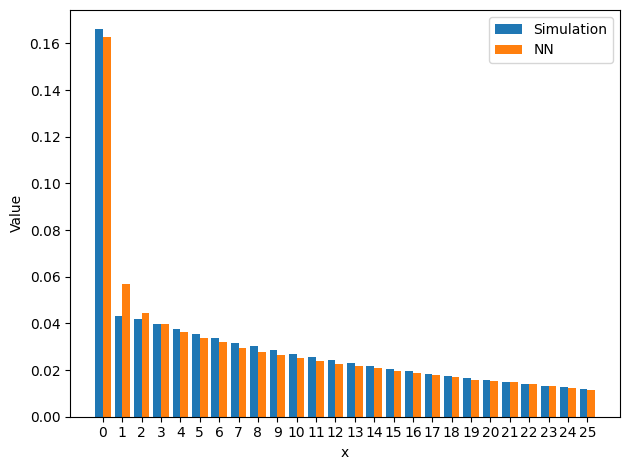

  0%|▏                                                                             | 1/500 [02:19<19:20:56, 139.59s/it]

3.528025347206301 0.055635282829476954
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
0.833999167475317 2.8780622312718664 3.1206854403526876 3.4935217994223047 -0.13093635154808575 0.1985970155141134
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@


  0%|▏                                                                             | 1/500 [02:41<22:19:13, 161.03s/it]


KeyboardInterrupt: 

In [10]:
for indd in tqdm(range(500)):

    moms_ser = {}
    services = {}
    arrivals = {}
    
    ind_map1 =  find_ind_with_domain_scv_maps(0, 3, maps) #np.random.randint(0, len(maps_high)) 
    ind_map2 = find_ind_with_domain_scv_maps(3, 20, maps) # np.random.randint(0, len(maps_low)) 
    a = 1.4
    DO_merged_a, D1_merged_a, res_map_a, arrivals, res_map_stream_1_a, res_map_stream_2_a = create_two_arrival_streams(maps, arrivals, 'a' ,  ind_map1, ind_map2, a = a)
    DO_merged_b, D1_merged_b, res_map_b, arrivals, res_map_stream_1_b, res_map_stream_2_b = create_two_arrival_streams(maps, arrivals,  'b' , ind_map1, ind_map2, a = a)
    
    rho = np.random.uniform(0.7,0.85)
    
    rho_a, rho_b, rho_c  = rho, rho,rho 
    ind_ph = np.random.randint(0, 100)
    
    tot_rate_a =  1/arrivals[( 'a', 0)].mean() + 1/arrivals[( 'a', 1)].mean()
    
    services, moms_ser, alpha_a, T_a = give_service_times(arrivals, phs, rho_a, 'a', services, moms_ser, tot_rate_a, ind_ph)
    tot_rate_b =  1/arrivals[( 'b', 0)].mean() + 1/arrivals[( 'b', 1)].mean()
    
    services, moms_ser,  alpha_b, T_b = give_service_times(arrivals, phs, rho_b, 'b', services, moms_ser, tot_rate_b, ind_ph)
    
    tot_rate_c = 1/arrivals[( 'b', 0)].mean() + 1/arrivals[( 'b', 1)].mean() + 1/arrivals[('a',0)].mean() + 1/arrivals[( 'a', 1)].mean()
    
    services, moms_ser,  alpha_c, T_c = give_service_times(arrivals, phs, rho_c, 'c', services, moms_ser, tot_rate_c, ind_ph)
    
    sim_time = 95000
    num_streams = 2
    queue_example1 = Queue_n_streams_2_tiers(arrivals, services, num_streams,sim_time)
    queue_example1.run()
    
    L_dist_c = queue_example1.num_cust_durations['c']/queue_example1.num_cust_durations['c'].sum()
    
    
    int_depart_a = np.array(queue_example1.inter_departure['a'])
    int_depart_b = np.array(queue_example1.inter_departure['b'])
    int_arrive = np.array(queue_example1.inter_arrivals_c)
    compute_scv_depart(int_depart_a), compute_scv_depart(int_depart_b), compute_scv_depart(int_arrive)
    
    int_depart_a1 = int_depart_a/int_depart_a.mean()
    int_depart_a1.mean()
    
    tot_inp_a = arange_inp_to_merge(res_map_stream_1_a, res_map_stream_2_a)
    tot_inp_b = arange_inp_to_merge(res_map_stream_1_b, res_map_stream_2_b)
    
    ## load the NN more moment merging
    
    input_size_moms, output_size_moms = 26, 4
    
    net_moms = Net_moms(input_size_moms, output_size_moms).to(device)
    
    input_size_corrs, output_size_corrs = 26, 8
    
    model_path = r'C:\Users\Eshel\workspace\MAP\models\moment_prediction' #r'C:\Users\Eshel\workspace\MAP\models'
    file_name_model_moms = 'model_num_97370_batch_size_64_curr_lr_0.001_num_moms_corrs_5_nn_archi_1_max_lag_2_max_power_1_2_max_power_2_2.pkl' #'merge_moments_1.pkl' #
    model_path_mom = r'C:\Users\Eshel\workspace\MAP\models'
    
    file_name_model_moms = 'merge_moments_1_small.pkl'
    model_path = r'C:\Users\Eshel\workspace\MAP\models'
    
    net_moms.load_state_dict(torch.load(os.path.join(model_path, file_name_model_moms)))
    net_moms.to(device)
    
    ## load the NN for corrs merging
    
    input_size_corrs, output_size_corrs = 26, 8
    nn_archi = 1
    net_corrs = get_nn_model(input_size_corrs, output_size_corrs, nn_archi) #Net_corrs(input_size_corrs, output_size_corrs) ##
    model_path_corrs = r'C:\Users\Eshel\workspace\MAP\models\corr_predicition'
    file_name_model_corrs = 'model_num_672478_batch_size_128_curr_lr_0.001_num_moms_corrs_5_nn_archi_1_max_lag_2_max_power_1_2_max_power_2_2.pkl'
    
    
    net_corrs = Net_corrs(input_size_corrs, output_size_corrs)
    model_path = r'C:\Users\Eshel\workspace\MAP\models'
    file_name_model_corrs = 'merge_corrs_1_small.pkl'
    
    net_corrs.load_state_dict(torch.load(os.path.join(model_path, file_name_model_corrs)))
    net_corrs = net_corrs.to(device)
    ## Get pred moms:
    
    ## predicting the moment and corrs for a and b
    
    moms_pred_a = net_moms(tot_inp_a.reshape(1, -1).to(device))
    corrs_pred_a = net_corrs(tot_inp_a.reshape(1, -1).to(device))
    
    
    moms_pred_b = net_moms(tot_inp_b.reshape(1, -1).to(device))
    corrs_pred_b = net_corrs(tot_inp_b.reshape(1, -1).to(device))
    
    moms_agg_a = give_moms_for_next_depart(tot_inp_a, moms_pred_a, corrs_pred_a, res_map_a)
    moms_agg_b = give_moms_for_next_depart(tot_inp_b, moms_pred_b, corrs_pred_b, res_map_b)
    
    ## uniting the input of stations 1 and 2
    
    inp_g_gi_1_a = torch.concatenate((moms_agg_a, corrs_pred_a.flatten())).reshape(1, -1)
    inp_g_gi_1_b = torch.concatenate((moms_agg_b, corrs_pred_b.flatten())).reshape(1, -1)
    
    moms_troch = {}
    
    ## we need that the arrival rate in each station will equal 1 so we scale
    
    mom_scaled_a = 1 / (1 / torch.exp(tot_inp_a[0]) + 1 / torch.exp(tot_inp_a[13]))
    mom_scaled_b = 1 / (1 / torch.exp(tot_inp_b[0]) + 1 / torch.exp(tot_inp_b[13]))
    
    
    moms_ser_a_norm = []
    for mom in range(1,6):
        moms_ser_a_norm.append(np.exp(moms_ser['a'])[mom-1]/(mom_scaled_a**mom))
    
    moms_troch['a'] = torch.log(torch.tensor(moms_ser_a_norm).to(device))
    
    moms_ser_b_norm = []
    for mom in range(1,6):
        moms_ser_b_norm.append(np.exp(moms_ser['b'])[mom-1]/(mom_scaled_b**mom))
    
    moms_troch['b'] = torch.log(torch.tensor(moms_ser_b_norm).to(device))
    
    input_steady_1_a = torch.concatenate((inp_g_gi_1_a, moms_troch['a'].reshape(1,-1)), axis=1)
    input_steady_1_b = torch.concatenate((inp_g_gi_1_b, moms_troch['b'].reshape(1,-1)), axis=1)
    
    
    net_depart_1_moms, net_depart_1_corrs  = load_depart_nn()
    
    depart_moms_station_a = net_depart_1_moms(input_steady_1_a)
    depart_moms_station_b = net_depart_1_moms(input_steady_1_b)
    
    depart_corrs_station_a = net_depart_1_corrs(input_steady_1_a)
    depart_corrs_station_b = net_depart_1_corrs(input_steady_1_b)
    
    # mom_ser_a = compute_first_n_moments(alpha_a, T_a ,1)[0].item()
    # T_a = T_a*mom_ser_a
    # compute_first_n_moments(alpha_a, T_a ,1)[0].item()
    # T_a = T_a/rho_a
    # compute_first_n_moments(alpha_a, T_a ,5)
    
    # mom_ser_b = compute_first_n_moments(alpha_b, T_b ,1)[0].item()
    # T_b = T_b*mom_ser_b
    # compute_first_n_moments(alpha_b, T_b ,1)[0].item()
    # T_b = T_b/rho_b
    # compute_first_n_moments(alpha_b, T_b ,1)[0].item()
    
    # D0d_a, D1d_a = build_departure_map_truncated(DO_merged_a.copy(), D1_merged_a.copy(), alpha_a.copy(), T_a.copy(), N=90)
    # moments_75 = map_interevent_moments(D0d_a, D1d_a, K=5)
    # 100*torch.abs(torch.exp(depart_moms_station_a).flatten() - torch.tensor(moments_75).to(device))/torch.tensor(moments_75).to(device)
    
    # D0d, D1d = build_departure_map_truncated(DO_merged_b.copy(), D1_merged_b.copy(), alpha_b.copy(), T_b.copy(), N=95)
    # moments_75 = map_interevent_moments(D0d, D1d, K=5)
    # 100*torch.abs(torch.exp(depart_moms_station_b).flatten() - torch.tensor(moments_75).to(device))/torch.tensor(moments_75).to(device)
    inp_stream_a = torch.concatenate((depart_moms_station_a, depart_corrs_station_a),axis = 1)
    inp_stream_b = torch.concatenate((depart_moms_station_b, depart_corrs_station_b),axis = 1)
    
    inp_merging_station_c = torch.concatenate((inp_stream_a, inp_stream_b),axis = 1)
    inp_merging_station_c.shape
    
    
    moms_pred_station_c = net_moms(inp_merging_station_c.to(device))
    corrs_pred_station_c = net_corrs(inp_merging_station_c.to(device))
    
    tot_arrive_rate_c =  1/torch.exp(input_steady_1_a)[0,0] + 1/torch.exp(input_steady_1_b)[0,0]
    with torch.no_grad():
        moms_pred_station_c_cpu = torch.exp(moms_pred_station_c.flatten().cpu())
    
    inter_arrive_c_arr = np.array(queue_example1.inter_arrivals_c)
    
    inter_arrive_c_arr = inter_arrive_c_arr/inter_arrive_c_arr.mean()
    inter_arrive_c_arr.mean()
    
    moms_arrive_c = [1]
    
    for mom in range(2,6):
        moms_arrive_c.append(moms_pred_station_c_cpu[mom-2]*(tot_arrive_rate_c**mom))
    
    moms_arrive_c_torch = torch.log(torch.tensor(moms_arrive_c)).to(device)
    
    # scale to 1
    
    mom1_c = np.exp(moms_ser['c'])[0]
    moms_c = []
    for mom in range(1,6):
        moms_c.append(np.exp(moms_ser['c'])[mom-1]/(mom1_c**mom))
    
    moms_c1 = []
    for mom in range(1,6):
        moms_c1.append(moms_c[mom-1]*(rho_c**mom))
    
    moms_troch['c']  =  torch.log(torch.tensor(moms_c1).to(device))
    
    
    inp_steady_1_station_c = torch.concatenate((moms_arrive_c_torch, corrs_pred_station_c.flatten(), moms_troch['c'])).reshape(1,-1)
    
    inp_steady_1_station_c = torch.tensor(inp_steady_1_station_c, dtype=torch.float32)
    
    input_size_steady_1 = 18
    output_size_steady_1 = 200
    
    file_name_model = 'for_tier_1.pkl'
    model_path = r'C:\Users\Eshel\workspace\data\models\steady_1'
    
    
    model_path_steady_1 = r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\steady_1'
    model_path_steady_1 = r'C:\Users\Eshel\workspace\data\models\steady_1'
    
    models_steady_1 = os.listdir(model_path_steady_1)
    
    full_path_steady_1 = os.path.join(model_path_steady_1, file_name_model) #models_steady_1[0]
    
    
    net_steady_1 = Net_steady_1(input_size_steady_1, output_size_steady_1).to(device)
    net_steady_1.load_state_dict(torch.load(full_path_steady_1))
    
    
    m = nn.Softmax(dim=1)
    # input_steady_1 = inp_g_gi_1
    
    probs_steady_1 = net_steady_1(inp_steady_1_station_c)
    normalizing_const = torch.exp(inp_steady_1_station_c[0, -5])
    probs_steady_1 = m(probs_steady_1)
    probs_steady_1 = probs_steady_1 * normalizing_const
    
    probs_steady_1 = probs_steady_1.to('cpu')
    probs_steady_1 = torch.concatenate((torch.tensor([[1 - normalizing_const]]), probs_steady_1[0:1, :]), axis=1)
    
    with torch.no_grad():
        label = probs_steady_1.cpu().numpy().flatten()
    
     # x values
    x = np.arange(26)  # 0,1,...,20
    
    # take first 21 values
    y1 = label[:26]
    y2 = L_dist_c[:26]
    
    bar_width = 0.4
    
    plt.figure()
    plt.bar(x - bar_width / 2, y1, width=bar_width, label='Simulation')
    plt.bar(x + bar_width / 2, y2, width=bar_width, label='NN')
    
    plt.xlabel('x')
    plt.ylabel('Value')
    plt.xticks(x)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    SAE = np.abs(label[:100] - L_dist_c[:100]).sum()
    EL_nn = (np.arange(L_dist_c.shape[0]) * L_dist_c).sum()
    EL_sim = (np.arange(label.shape[0]) * label).sum()
    
    error_nn = 100 * abs(EL_nn - EL_sim) / EL_sim
    print(error_nn, SAE)
    
    SCV_1 = maps[ind_map1]['scv']
    SCV_2 = maps[ind_map2]['scv']
    
    rho_a = maps[ind_map1]['rho1']
    rho_b = maps[ind_map2]['rho1']
    
    SCV_ser = phs[ind_ph]['scv']
    print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
    print(rho,   SCV_1, SCV_2,  SCV_ser, rho_a, rho_b)
    print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')
    
    dump_path = r'C:\Users\Eshel\workspace\MAP\results_queues\tier_2_non_renewal'
    if error_nn < 10:
        pkl.dump(( label, L_dist_c, rho,a, error_nn,   SCV_1, SCV_2,
                  SCV_ser, rho_a, rho_b,  SAE),
                     open(os.path.join(dump_path, 'result_{}.pkl'.format(np.random.randint(1,1000000))), 'wb'))

In [1074]:
ind_map1, ind_map2

(5539, 6268)

In [1083]:
a

1.5

In [1084]:
SCV_ser

array([5.27409409])

In [1012]:
D0d_a, D1d_a = build_departure_map_truncated(DO_merged_a.copy(), D1_merged_a.copy(), alpha_a.copy(), T_a.copy(), N=90)
map_lag1_autocorrelation(D0d_a, D1d_a)

C:\Users\Eshel\AppData\Local\Temp\ipykernel_36896\2930002644.py:413: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lam = float(pi @ D1 @ e)
C:\Users\Eshel\AppData\Local\Temp\ipykernel_36896\2930002644.py:423: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  EX = float(alpha @ m1_vec)
C:\Users\Eshel\AppData\Local\Temp\ipykernel_36896\2930002644.py:427: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  EX2 = float(2 * (alpha @ m2_vec))
C:\Users\Eshel\AppData\Local\Temp\ipyk

0.044452665506991035

torch.Size([1, 26])

In [1030]:
inp_merging_station_c.shape

torch.Size([1, 26])

In [1026]:
torch.exp(moms_pred_station_c)

tensor([[0.4817, 0.8305, 2.0953, 7.0021]], device='cuda:0',
       grad_fn=<ExpBackward0>)

In [1034]:
torch.exp(inp_merging_station_c[0,13:])

tensor([  1.0000,   2.2514,   9.1360,  53.6709, 419.0196,   1.0391,   1.0289,
          1.0346,   1.0264,   1.0255,   1.0184,   1.0243,   1.0177],
       device='cuda:0', grad_fn=<ExpBackward0>)

In [1028]:
compute_scv_depart(int_arrive)

np.float64(1.026988499418122)

In [1035]:
(0.4817-0.25)/0.25

0.9268000000000001

In [1039]:
moms_troch

{'a': tensor([-0.3568, -0.1918,  0.3430,  1.1831,  2.2861], device='cuda:0'),
 'b': tensor([-0.4326, -0.2219,  0.3916,  1.3041,  2.4524], device='cuda:0')}

C:\Users\Eshel\AppData\Local\Temp\ipykernel_36896\1649646171.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inp_steady_1_station_c = torch.tensor(inp_steady_1_station_c, dtype=torch.float32)


C:\Users\Eshel\AppData\Local\Temp\ipykernel_36896\914254190.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_steady_1.load_state_dict(torch.load(full_path_steady_1))

<All keys matched successfully>

In [1049]:
label[:10]

array([0.25      , 0.17452307, 0.1253795 , 0.09365829, 0.0717416 ,
       0.05595172, 0.04412096, 0.03521761, 0.02826151, 0.02280232],
      dtype=float32)

In [1051]:
L_dist_c

array([1.48210386e-01, 4.79598461e-02, 3.42580208e-02, 2.91306251e-02,
       2.61420483e-02, 2.41778833e-02, 2.32686157e-02, 2.23164789e-02,
       2.11542719e-02, 2.06349988e-02, 1.97152650e-02, 1.87749111e-02,
       1.82234219e-02, 1.74493469e-02, 1.74511004e-02, 1.70568445e-02,
       1.66203401e-02, 1.58633810e-02, 1.55429294e-02, 1.49774632e-02,
       1.49000369e-02, 1.35788072e-02, 1.35368948e-02, 1.30681655e-02,
       1.25823819e-02, 1.24225452e-02, 1.19172543e-02, 1.16795589e-02,
       1.14196591e-02, 1.10590301e-02, 1.04631314e-02, 1.03964751e-02,
       9.92662581e-03, 9.53680786e-03, 9.00603505e-03, 8.38940935e-03,
       8.59843941e-03, 8.24480680e-03, 7.82605996e-03, 7.59099927e-03,
       7.25584182e-03, 7.13246339e-03, 7.39932741e-03, 6.77477877e-03,
       6.54130563e-03, 6.20781078e-03, 6.04989264e-03, 5.68623669e-03,
       5.47621860e-03, 5.19677340e-03, 5.13418825e-03, 4.89123650e-03,
       4.60984326e-03, 4.50979293e-03, 4.31540968e-03, 4.29975966e-03,
      

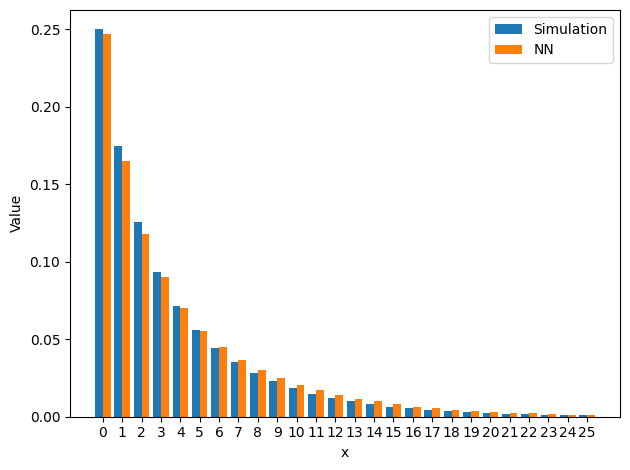

In [1058]:
np.abs(label[:120] - L_dist_c[:120]).sum()

np.float64(0.05182852746396123)

(np.float64(9.088029903937372), np.float64(0.05182852444491724))

In [647]:
a = 1.5 # np.random.uniform(1, 5)

ind_map1 =  np.random.randint(0, len(maps)) 
ind_map2 = np.random.randint(0, len(maps)) 

D0a, D1a = (1 / (a - 1)) * maps[ind_map1]['D0'].copy(),    (1 / (a - 1)) * maps[ind_map1]['D1'].copy()

mom1a = create_mom_cor_vector(D0a.copy(), D1a.copy())[0]

D0b, D1b =  maps[ind_map2]['D0'].copy(), maps[ind_map2]['D1'].copy()

mom1b = create_mom_cor_vector(D0b.copy(), D1b.copy())[0]

print('mom1 a {}, mom1 b {}' .format(mom1a, mom1b))

DO_merged_a, D1_merged_a = superpose_map(D0a.copy(), D1a.copy(), D0b.copy(), D1b.copy())

res_map_stream_1_a = create_mom_cor_vector(D0a.copy(), D1a.copy())
res_map_stream_2_a = create_mom_cor_vector(D0b.copy(), D1b.copy())


mom1 = create_mom_cor_vector(DO_merged_a.copy(), D1_merged_a.copy())[0]
print('mom1 merged {}' .format(mom1))
DO_merged_a, D1_merged_a = DO_merged_a * mom1, D1_merged_a * mom1
res_map_a = create_mom_cor_vector(DO_merged_a, D1_merged_a)
print('first five merged moms nomrzilzed to mean 1 {}'.format(res_map[:5]))
res_map_a[:10] = np.log(res_map_a[:10])

num_streams = 2


arrivals[('a', 0)] = SamplesFromMAP(ml.matrix(D0a.copy()), ml.matrix(D1a.copy()),1000000)
arrivals[ ('a', 0)].mean()

arrivals[( 'a', 1)] = SamplesFromMAP(ml.matrix(D0b.copy()), ml.matrix(D1b.copy()),1000000)
arrivals[( 'a',1)].mean()

mom1 a 0.5, mom1 b 1.0
mom1 merged 0.33333333333333337
first five merged moms nomrzilzed to mean 1 [4.44089210e-16 1.31046117e+00 3.07542908e+00 5.13648910e+00
 7.42379130e+00]


np.float64(0.9995948804224598)

In [595]:
a = 1.5 # np.random.uniform(1, 5)

ind_map1 =  np.random.randint(0, len(maps)) # choose_scv_lower_3(maps)  #
ind_map2 = np.random.randint(0, len(maps)) # choose_scv_larger_3(maps)  # np.random.randint(0, 500)

D0a, D1a = (1 / (a - 1)) * maps[ind_map1]['D0'].copy(),    (1 / (a - 1)) * maps[ind_map1]['D1'].copy()

mom1a = create_mom_cor_vector(D0a.copy(), D1a.copy())[0]

D0b, D1b =  maps[ind_map2]['D0'].copy(), maps[ind_map2]['D1'].copy()

mom1b = create_mom_cor_vector(D0b.copy(), D1b.copy())[0]

print('mom1 a {}, mom1 b {}' .format(mom1a, mom1b))

DO_merged_b, D1_merged_b = superpose_map(D0a.copy(), D1a.copy(), D0b.copy(), D1b.copy())
res_map_stream_1_b = create_mom_cor_vector(D0a.copy(), D1a.copy())
res_map_stream_2_b = create_mom_cor_vector(D0b.copy(), D1b.copy())


mom1 = create_mom_cor_vector(DO_merged_b.copy(), D1_merged_b.copy())[0]
print('mom1 merged {}' .format(mom1))
DO_merged_b, D1_merged_b = DO_merged_b * mom1, D1_merged_b * mom1
res_map_b = create_mom_cor_vector(DO_merged_b.copy(), D1_merged_b.copy())
print('first five merged moms nomrzilzed to mean 1 {}'.format(res_map[:5]))
res_map_b[:10] = np.log(res_map_b[:10])

num_streams = 2

arrivals[( 'b',0)] = SamplesFromMAP(ml.matrix(D0a.copy()), ml.matrix(D1a.copy()),1000000)
arrivals[( 'b', 0)].mean()

arrivals[( 'b', 1)] = SamplesFromMAP(ml.matrix(D0b.copy()), ml.matrix(D1b.copy()),1000000)
arrivals[( 'b',1)].mean()

mom1 a 0.49999999999999994, mom1 b 1.0000000000000004
mom1 merged 0.3333333333333336
first five merged moms nomrzilzed to mean 1 [4.44089210e-16 1.31046117e+00 3.07542908e+00 5.13648910e+00
 7.42379130e+00]


np.float64(1.0039281956473436)

In [53]:
1/arrivals[(0, 'b')].mean() + 1/arrivals[(1, 'b')].mean() + 1/arrivals[(0, 'a')].mean() + 1/arrivals[(1, 'a')].mean()

np.float64(2.99886172287235)

In [596]:
rho_a = 0.85
tot_arrival_a = 1/arrivals[( 'a', 0)].mean() + 1/arrivals[( 'a', 1)].mean()
mean_ser_a = rho_a/tot_arrival_a
mean_ser_a

np.float64(0.2835007111602371)

In [597]:
ind_ph = np.random.randint(0, 100)
alpha, T = phs[ind_ph]['alpha'], phs[ind_ph]['T']
T = T * phs[ind_ph]['mean']
T = T / mean_ser_a
res_ph = compute_first_n_moments(alpha, T, 10)
services['a'] = SamplesFromPH(ml.matrix(alpha), ml.matrix(T), 1000000)
moms_ser['a'] = np.log(np.array(res_ph).flatten())

In [598]:
rho_b = 0.85
tot_arrival_b = 1/arrivals[( 'b', 0)].mean() + 1/arrivals[( 'b', 1)].mean()
mean_ser_b = rho_b/tot_arrival_b
mean_ser_b

np.float64(0.28354656387299565)

In [599]:
ind_ph = np.random.randint(0, 100)
alpha, T = phs[ind_ph]['alpha'], phs[ind_ph]['T']
T = T * phs[ind_ph]['mean']
T = T / mean_ser_b
res_ph = compute_first_n_moments(alpha, T, 10)
services['b'] = SamplesFromPH(ml.matrix(alpha), ml.matrix(T), 1000000)
moms_ser['b'] = np.log(np.array(res_ph).flatten())

In [600]:
rho_c = 0.85
mean_ser_c = rho_c/arrival_tot_c_rate
mean_ser_c

np.float64(0.1416445406987419)

In [601]:
ind_ph = np.random.randint(0, 100)
alpha, T = phs[ind_ph]['alpha'], phs[ind_ph]['T']
T = T * phs[ind_ph]['mean']
T = T / mean_ser_c
res_ph = compute_first_n_moments(alpha, T, 10)
services['c'] = SamplesFromPH(ml.matrix(alpha), ml.matrix(T), 1000000)
moms_ser['c'] = np.log(np.array(res_ph).flatten())

In [501]:
services

{'a': array([0.05660091, 0.04043298, 0.17265266, ..., 0.0879537 , 0.42094517,
        0.00715435]),
 'b': array([0.12283239, 0.10905102, 0.04397252, ..., 0.01594578, 0.13436236,
        0.02526227]),
 'c': array([0.13976398, 0.79726824, 0.08741416, ..., 0.17916126, 0.02296263,
        0.12918427])}

In [533]:
1/arrivals[('a', 0)].mean() + 1/arrivals[('a', 1)].mean()

np.float64(3.000326479247636)

In [534]:
1/arrivals[('b', 0)].mean() + 1/arrivals[('b', 1)].mean()

np.float64(2.996556607684137)

In [602]:
sim_time = 95000

queue_example1 = Queue_n_streams_2_tiers(arrivals, services, num_streams,sim_time)
queue_example1.run()

L_dist_a = queue_example1.num_cust_durations['a']/queue_example1.num_cust_durations['a'].sum()
L_dist_a[:15]

array([0.14650799, 0.03917364, 0.03209122, 0.02751856, 0.02549356,
       0.02409944, 0.0229882 , 0.02191534, 0.02114179, 0.0208057 ,
       0.0199356 , 0.01992659, 0.01816373, 0.01862494, 0.01689165])

In [603]:
int_arrive = np.array(queue_example1.inter_arrivals_c)

In [641]:
int_depart_a = np.array(queue_example1.inter_departure['a'])
int_depart_b = np.array(queue_example1.inter_departure['b'])

In [605]:
((int_depart_a**2).mean()-int_depart_a.mean()**2)/int_depart_a.mean()**2, ((int_depart_b**2).mean()-int_depart_b.mean()**2)/int_depart_b.mean()**2

(np.float64(4.617527538521935), np.float64(3.3826549982795426))

In [482]:
int_depart_a.mean()

np.float64(0.6690754048835565)

In [642]:
((int_depart_a**2).mean()-int_depart_a.mean()**2)/int_depart_a.mean()**2, ((int_depart_b**2).mean()-int_depart_b.mean()**2)/int_depart_b.mean()**2

(np.float64(4.617527538521935), np.float64(3.3826549982795426))

In [607]:
((int_arrive**2).mean()-int_arrive.mean()**2)/int_arrive.mean()**2

np.float64(3.03997741812661)

In [608]:
L_dist_c = queue_example1.num_cust_durations['c']/queue_example1.num_cust_durations['c'].sum()
L_dist_c[:5]

array([0.14821039, 0.04795985, 0.03425802, 0.02913063, 0.02614205])

In [100]:
res_map_stream_1_a[0], res_map_stream_2_a[0]

(np.float64(2.0000000000000004), np.float64(1.0))

In [609]:
# step 2 cont'
max_lag = 2
max_power_1 = 2
max_power_2 = 2
num_arrive_moms = 5
df = pd.DataFrame([])

for corr_leg in range(1, 6):
    for mom_1 in range(1, 6):
        for mom_2 in range(1, 6):
            curr_ind = df.shape[0]
            df.loc[curr_ind, 'lag'] = corr_leg
            df.loc[curr_ind, 'mom_1'] = mom_1
            df.loc[curr_ind, 'mom_2'] = mom_2
            df.loc[curr_ind, 'index'] = curr_ind + 10

inp1_moms_a = res_map_stream_1_a[:num_arrive_moms]
inp2_moms_a = res_map_stream_2_a[:num_arrive_moms]

inp1_corrs_a = res_map_stream_1_a[
    df.loc[(df['lag'] <= max_lag) & (df['mom_1'] <= max_power_1) & (df['mom_2'] <= max_power_2), :].index + 10]
inp2_corrs_a = res_map_stream_2_a[
    df.loc[(df['lag'] <= max_lag) & (df['mom_1'] <= max_power_1) & (df['mom_2'] <= max_power_2), :].index + 10]


inp1_moms_b = res_map_stream_1_b[:num_arrive_moms]
inp2_moms_b = res_map_stream_2_b[:num_arrive_moms]

inp1_corrs_b = res_map_stream_1_b[
    df.loc[(df['lag'] <= max_lag) & (df['mom_1'] <= max_power_1) & (df['mom_2'] <= max_power_2), :].index + 10]
inp2_corrs_b = res_map_stream_2_b[
    df.loc[(df['lag'] <= max_lag) & (df['mom_1'] <= max_power_1) & (df['mom_2'] <= max_power_2), :].index + 10]




In [610]:
tot_inp_a = np.concatenate((np.log(inp1_moms_a), inp1_corrs_a, np.log(inp2_moms_a), inp2_corrs_a))
tot_inp_a = torch.tensor(tot_inp_a, dtype=torch.float32)
tot_inp_a

tensor([-0.6931,  0.0289,  1.1929,  2.6722,  4.3965,  0.1514,  0.0771,  0.0771,
         0.0399,  0.0701,  0.0352,  0.0352,  0.0178,  0.0000,  1.3846,  3.1801,
         5.2662,  7.5783, -0.1302, -0.0677, -0.0677, -0.0352,  0.0513,  0.0267,
         0.0267,  0.0139])

In [542]:
inp1_moms_a, inp2_moms_a

(array([ 0.5       ,  0.77741313,  2.02738874,  7.24485189, 32.76563708]),
 array([1.00000000e+00, 3.69698833e+00, 2.26308694e+01, 1.91692787e+02,
        2.08115438e+03]))

In [541]:
inp1_moms_b, inp2_moms_b

(array([ 0.5       ,  1.01156754,  3.1369714 , 13.1846969 , 70.27573869]),
 array([  1.        ,   2.03091029,   6.27707586,  26.21748219,
        138.5669043 ]))

In [611]:
tot_inp_b = np.concatenate((np.log(inp1_moms_b), inp1_corrs_b, np.log(inp2_moms_b), inp2_corrs_b))
tot_inp_b = torch.tensor(tot_inp_b, dtype=torch.float32)

In [544]:
torch.exp(tot_inp_b)

tensor([  0.5000,   1.0116,   3.1370,  13.1847,  70.2757,   0.8938,   0.9448,
          0.9448,   0.9720,   1.0406,   1.0205,   1.0205,   1.0105,   1.0000,
          2.0309,   6.2771,  26.2175, 138.5669,   1.0008,   1.0007,   1.0007,
          1.0006,   1.0000,   1.0000,   1.0000,   1.0000])

In [612]:


input_size_moms, output_size_moms = 26, 4

net_moms = Net_moms(input_size_moms, output_size_moms).to(device)

input_size_corrs, output_size_corrs = 26, 8

model_path = r'C:\Users\Eshel\workspace\MAP\models\moment_prediction' #r'C:\Users\Eshel\workspace\MAP\models'
file_name_model_moms = 'model_num_97370_batch_size_64_curr_lr_0.001_num_moms_corrs_5_nn_archi_1_max_lag_2_max_power_1_2_max_power_2_2.pkl' #'merge_moments_1.pkl' #
model_path_mom = r'C:\Users\Eshel\workspace\MAP\models'

file_name_model_moms = 'merge_moments_1_small.pkl'
model_path = r'C:\Users\Eshel\workspace\MAP\models'

net_moms.load_state_dict(torch.load(os.path.join(model_path, file_name_model_moms)))
net_moms.to(device)

input_size_corrs, output_size_corrs = 26, 8
nn_archi = 1
net_corrs = get_nn_model(input_size_corrs, output_size_corrs, nn_archi) #Net_corrs(input_size_corrs, output_size_corrs) ##
model_path_corrs = r'C:\Users\Eshel\workspace\MAP\models\corr_predicition'
file_name_model_corrs = 'model_num_672478_batch_size_128_curr_lr_0.001_num_moms_corrs_5_nn_archi_1_max_lag_2_max_power_1_2_max_power_2_2.pkl'

class Net_corrs(nn.Module):

    def __init__(self, input_size, output_size):
        
        super().__init__()
        
        self.fc1 = nn.Linear(input_size , 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, output_size)


    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x  


net_corrs = Net_corrs(input_size_corrs, output_size_corrs)
model_path = r'C:\Users\Eshel\workspace\MAP\models'
file_name_model_corrs = 'merge_corrs_1_small.pkl'

net_corrs.load_state_dict(torch.load(os.path.join(model_path, file_name_model_corrs)))
net_corrs = net_corrs.to(device)
## Get pred moms:

moms_pred_a = net_moms(tot_inp_a.reshape(1, -1).to(device))
corrs_pred_a = net_corrs(tot_inp_a.reshape(1, -1).to(device))


moms_pred_b = net_moms(tot_inp_b.reshape(1, -1).to(device))
corrs_pred_b = net_corrs(tot_inp_b.reshape(1, -1).to(device))


C:\Users\Eshel\AppData\Local\Temp\ipykernel_36896\438694649.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_moms.load_state_dict(torch.load(os.path.join(model_path,

In [512]:
output_size_corrs

8

In [111]:
np.exp(res_map[:5])

array([1.00000000e+00, 3.70788327e+00, 2.16591734e+01, 1.70117453e+02,
       1.67537333e+03])

In [613]:
moms_scaled = 1 / (1 / torch.exp(tot_inp_a[0]) + 1 / torch.exp(tot_inp_a[13]))

moms_a = [1]

for mom in range(1, 5):
    moms_a.append(torch.exp(moms_pred_a[0, mom - 1]) / (moms_scaled ** (mom + 1)))

moms_torch_a = torch.tensor(moms_a).to(device)
print('###########################')
print(100*torch.abs(torch.tensor(np.exp(res_map_a[:5])).to(device) - moms_torch_a)/moms_torch_a)
print(torch.abs(torch.tensor(res_map_a[10:12]).to(device) - corrs_pred_a.flatten()[:2]) )
print('###########################')

# for mom in range(5):
#     moms_torch_a[mom] = np.exp(res_map_a[mom]).item()

moms_agg_a = torch.log(moms_torch_a)


###########################
tensor([4.4409e-14, 3.6661e-01, 5.1464e-01, 4.9411e-01, 6.0233e-02],
       device='cuda:0', dtype=torch.float64)
tensor([0.0007, 0.0003], device='cuda:0', dtype=torch.float64,
       grad_fn=<AbsBackward0>)
###########################


In [444]:
corrs_pred_a[0][0]  = res_map_a[10].item()
corrs_pred_a[0][1]  = res_map_a[11].item()

In [295]:
moms_torch_a

tensor([1.0000e+00, 3.9862e+00, 2.4467e+01, 2.0295e+02, 2.1302e+03],
       device='cuda:0')

In [293]:
moms_torch_a

tensor([1.0000e+00, 3.4812e+00, 2.3350e+01, 2.2378e+02, 2.7656e+03],
       device='cuda:0')

In [292]:
np.exp(res_map_a[:5])

array([1.00000000e+00, 3.98621168e+00, 2.44666777e+01, 2.02949575e+02,
       2.13017024e+03])

In [517]:
torch.exp(tot_inp_b)

tensor([5.0000e-01, 6.4156e-01, 1.4478e+00, 4.7367e+00, 2.0224e+01, 1.1013e+00,
        1.0653e+00, 1.0653e+00, 1.0428e+00, 1.0586e+00, 1.0373e+00, 1.0373e+00,
        1.0240e+00, 1.0000e+00, 2.8779e+00, 1.3900e+01, 9.1818e+01, 7.6218e+02,
        9.5455e-01, 9.7249e-01, 9.7249e-01, 9.8341e-01, 1.0093e+00, 1.0056e+00,
        1.0056e+00, 1.0033e+00])

In [614]:
moms_scaled = 1 / (1 / torch.exp(tot_inp_b[0]) + 1 / torch.exp(tot_inp_b[13]))

moms_b = [1]

for mom in range(1, 5):
    moms_b.append(torch.exp(moms_pred_b[0, mom - 1]) / (moms_scaled ** (mom + 1)))

moms_torch_b = torch.tensor(moms_a).to(device)
print('###########################')
print(100*torch.abs(torch.tensor(np.exp(res_map_b[:5])).to(device) - moms_torch_b)/moms_torch_b)
print(torch.abs(torch.tensor(res_map_b[10:12]).to(device) - corrs_pred_b.flatten()[:2]) )
print('###########################')

# for mom in range(5):
#     moms_torch_b[mom] = np.exp(res_map_b[mom]).item()

moms_agg_b = torch.log(moms_torch_b)



###########################
tensor([0.0000, 1.2302, 3.4907, 5.1730, 6.5486], device='cuda:0',
       dtype=torch.float64)
tensor([0.0014, 0.0011], device='cuda:0', dtype=torch.float64,
       grad_fn=<AbsBackward0>)
###########################


In [523]:
np.exp(res_map_b[:5]) , moms_torch_b

(array([  1.        ,   2.43727966,  10.31983927,  63.73011044,
        517.33404762]),
 tensor([  1.0000,   2.9432,  13.9333,  90.5854, 750.1087], device='cuda:0'))

In [446]:
corrs_pred_b[0][0]  = res_map_b[10].item()
corrs_pred_b[0][1]  = res_map_b[11].item()

In [267]:
np.exp(res_map_b[:5])

array([  1.        ,   3.02594529,  14.08614896,  88.9177532 ,
       712.3562997 ])

In [265]:
moms_torch_b

tensor([1.0000e+00, 3.4812e+00, 2.3350e+01, 2.2378e+02, 2.7656e+03],
       device='cuda:0')

In [122]:
moms_agg_b

tensor([0.0000, 1.1254, 2.9118, 5.0625, 7.4689], device='cuda:0')

In [123]:
res_map_b[:5]

array([4.44089210e-16, 1.07634895e+00, 2.67049501e+00, 4.58856067e+00,
       6.74321007e+00])

In [615]:
inp_g_gi_1_a = torch.concatenate((moms_agg_a, corrs_pred_a.flatten())).reshape(1, -1)
inp_g_gi_1_b = torch.concatenate((moms_agg_b, corrs_pred_b.flatten())).reshape(1, -1)

moms_troch = {}

mom_scaled_a = 1 / (1 / torch.exp(tot_inp_a[0]) + 1 / torch.exp(tot_inp_a[13]))

mom_scaled_b = 1 / (1 / torch.exp(tot_inp_b[0]) + 1 / torch.exp(tot_inp_b[13]))


In [384]:
moms_ser

{'b': array([-0.56939085,  0.56412637,  2.38928558,  4.5370062 ,  6.9114104 ,
         9.46848791, 12.17975097, 15.02454888, 17.98713017, 21.05507201]),
 'c': array([-1.26186848, -0.43661474,  1.10302347,  2.9533796 ,  5.02831102,
         7.28565183,  9.6971487 , 12.2421773 , 14.90498895, 17.67316112]),
 'a': array([-0.56781507,  0.79710844,  2.86876811,  5.25530725,  7.86703548,
        10.66123671, 13.60959982, 16.69149515, 19.89117357, 23.19621251])}

In [617]:
moms_ser_a_norm = []
for mom in range(1,6):
    moms_ser_a_norm.append(np.exp(moms_ser['a'])[mom-1]/(mom_scaled_a**mom))

moms_troch['a'] = torch.log(torch.tensor(moms_ser_a_norm).to(device))

moms_ser_b_norm = []
for mom in range(1,6):
    moms_ser_b_norm.append(np.exp(moms_ser['b'])[mom-1]/(mom_scaled_b**mom))

moms_troch['b'] = torch.log(torch.tensor(moms_ser_b_norm).to(device))

moms_troch

{'a': tensor([-0.1619,  1.5621,  3.9903,  6.7347,  9.7046], device='cuda:0'),
 'b': tensor([-0.1618,  1.2639,  3.3712,  5.8058,  8.4682], device='cuda:0')}

In [552]:
torch.exp(moms_troch['a'])

tensor([8.4991e-01, 3.8083e+00, 3.3967e+01, 4.1893e+02, 6.4840e+03],
       device='cuda:0')

In [331]:
np.exp(moms_ser['a'])[0]/(mom_scaled_a)

tensor(0.8493)

In [139]:
moms_agg_a

tensor([0.0000, 1.1208, 2.8516, 4.9630, 7.3514], device='cuda:0')

In [151]:
inp_g_gi_1_a

tensor([[0.0000, 1.1208, 2.8516, 4.9630, 7.3514, 0.1049, 0.0575, 0.0579, 0.0338,
         0.0502, 0.0272, 0.0276, 0.0176]], device='cuda:0',
       grad_fn=<ViewBackward0>)

In [453]:
inp_g_gi_1_a.shape

torch.Size([1, 13])

In [618]:
input_steady_1_a = torch.concatenate((inp_g_gi_1_a, moms_troch['a'].reshape(1,-1)), axis=1)
input_steady_1_b = torch.concatenate((inp_g_gi_1_b, moms_troch['b'].reshape(1,-1)), axis=1)

In [644]:
class Net_depart_1_moms(nn.Module):

    # def __init__(self, input_size, output_size):
    #     super().__init__()

    #     self.fc1 = nn.Linear(input_size, 50)
    #     self.fc2 = nn.Linear(50, 70)
    #     self.fc3 = nn.Linear(70, 50)
    #     self.fc4 = nn.Linear(50, output_size)

    # def forward(self, x):
    #     x = F.relu(self.fc1(x))
    #     x = F.relu(self.fc2(x))
    #     x = F.relu(self.fc3(x))
    #     x = self.fc4(x)
    #     return x

    def __init__(self, input_size, output_size):
        
        super().__init__()
        
        self.fc1 = nn.Linear(input_size , 50)
        self.fc2 = nn.Linear(50, 50)
        # self.fc3 = nn.Linear(70, 50)
        self.fc3 = nn.Linear(50, output_size)


    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # x = F.relu(self.fc3(x))
        x = self.fc3(x)
        return x  

class Net_depart_1_corrs(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x



model_path_depart_1_moms = r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\depart_1_moms'
model_path_depart_1_cors = r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\depart_1_cors'



models_depart_1_moms =  os.listdir(model_path_depart_1_moms)
models_depart_1_cors =  os.listdir(model_path_depart_1_cors)


file_name_model_name = 'depart_moms_for_tier_1a.pkl'

    
model_path_depart_1_moms = r'C:\Users\Eshel\workspace\data\models\depart_1_moms' # r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\depart_1_moms'
model_path_depart_1_cors = r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\depart_1_cors'



models_depart_1_moms =  os.listdir(model_path_depart_1_moms)
models_depart_1_cors =  os.listdir(model_path_depart_1_cors)

full_path_depart_1_moms = os.path.join(model_path_depart_1_moms, file_name_model_name)


full_path_depart_1_cors = os.path.join(model_path_depart_1_cors, models_depart_1_cors[0])


input_size_depart_1_moms = 18
output_size_depart_1_moms = 5
net_depart_1_moms = Net_depart_1_moms(input_size_depart_1_moms, output_size_depart_1_moms).to(device)
net_depart_1_moms.load_state_dict(torch.load(full_path_depart_1_moms))

# print(net_depart_1_moms)

input_size_depart_1_corrs = 18
output_size_depart_1_corrs = 8
net_depart_1_corrs = Net_depart_1_corrs(input_size_depart_1_corrs, output_size_depart_1_corrs).to(device)
net_depart_1_corrs.load_state_dict(torch.load(full_path_depart_1_cors))

C:\Users\Eshel\AppData\Local\Temp\ipykernel_36896\58212798.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_depart_1_moms.load_state_dict(torch.load(full_path_depart

<All keys matched successfully>

In [576]:
input_steady_1_a

tensor([[ 0.0000,  1.1339,  2.7774,  4.7498,  6.9713, -0.0564, -0.0359, -0.0359,
         -0.0225,  0.0359,  0.0219,  0.0220,  0.0138, -0.1626,  1.3372,  3.5254,
          6.0377,  8.7771]], device='cuda:0', grad_fn=<CatBackward0>)

In [645]:
torch.exp(input_steady_1_a)[0][:5]

tensor([1.0000e+00, 4.0148e+00, 2.5025e+01, 2.0910e+02, 2.2004e+03],
       device='cuda:0', grad_fn=<SliceBackward0>)

In [582]:
np.exp(res_map_a[:5])

array([1.00000000e+00, 3.04857230e+00, 1.60175169e+01, 1.16647171e+02,
       1.07858733e+03])

In [586]:
input_steady_1_a[0][5:7], res_map_a[10:12]

(tensor([-0.0564, -0.0359], device='cuda:0', grad_fn=<SliceBackward0>),
 array([-0.05904579, -0.03595791]))

In [590]:
import numpy as np

def lag1_autocorrelation(x):
    x = np.asarray(x)

    if x.ndim != 1:
        raise ValueError("Input must be a 1D array")

    n = len(x)
    if n < 2:
        return np.nan

    x_mean = np.mean(x)
    x0 = x[:-1] - x_mean
    x1 = x[1:]  - x_mean

    cov = np.dot(x0, x1) / (n - 1)
    var = np.var(x, ddof=1)

    if var == 0:
        return np.nan

    return cov / var

lag1_autocorrelation(int_depart_a)

np.float64(-0.007372263327594112)

In [589]:
int_depart_a

array([0.62278765, 0.0432254 , 0.8435387 , ..., 0.09150029, 0.10755277,
       0.09205077])

In [456]:
depart_moms_station_a = net_depart_1_moms(input_steady_1_a)
depart_moms_station_b = net_depart_1_moms(input_steady_1_b)

depart_corrs_station_a = net_depart_1_corrs(input_steady_1_a)
depart_corrs_station_b = net_depart_1_corrs(input_steady_1_b)




In [591]:
depart_corrs_station_a

tensor([[0.0252, 0.0265, 0.0344, 0.0309, 0.0251, 0.0229, 0.0297, 0.0257]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [587]:
depart_corrs_station_a

tensor([[0.0252, 0.0265, 0.0344, 0.0309, 0.0251, 0.0229, 0.0297, 0.0257]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
(3.547395741845931), np.float64(5.70380616359203))

In [639]:
torch.exp(depart_moms_station_a)

tensor([[  1.0000,   2.5498,  11.5637,  78.8553, 731.0288]], device='cuda:0',
       grad_fn=<ExpBackward0>)

In [577]:
torch.exp(depart_moms_station_b) - 1

tensor([[0.0000e+00, 3.6944e+00, 3.8518e+01, 4.7927e+02, 7.4465e+03]],
       device='cuda:0', grad_fn=<SubBackward0>)

In [621]:
inp_stream_a = torch.concatenate((depart_moms_station_a, depart_corrs_station_a),axis = 1)
inp_stream_b = torch.concatenate((depart_moms_station_b, depart_corrs_station_b),axis = 1)

inp_merging_station_c = torch.concatenate((inp_stream_a, inp_stream_b),axis = 1)
inp_merging_station_c.shape

torch.Size([1, 26])

In [622]:
torch.exp(depart_moms_station_a), torch.exp(depart_moms_station_b)

(tensor([[  1.0000,   2.5498,  11.5637,  78.8553, 731.0288]], device='cuda:0',
        grad_fn=<ExpBackward0>),
 tensor([[1.0000e+00, 4.6944e+00, 3.9518e+01, 4.8027e+02, 7.4475e+03]],
        device='cuda:0', grad_fn=<ExpBackward0>))

In [623]:
input_steady_1_a

tensor([[ 0.0000,  1.3900,  3.2199,  5.3428,  7.6964,  0.0584,  0.0308,  0.0307,
          0.0170,  0.0408,  0.0216,  0.0219,  0.0123, -0.1619,  1.5621,  3.9903,
          6.7347,  9.7046]], device='cuda:0', grad_fn=<CatBackward0>)

In [624]:
torch.exp(inp_merging_station_c)

tensor([[1.0000e+00, 2.5498e+00, 1.1564e+01, 7.8855e+01, 7.3103e+02, 1.0255e+00,
         1.0268e+00, 1.0350e+00, 1.0313e+00, 1.0254e+00, 1.0232e+00, 1.0301e+00,
         1.0260e+00, 1.0000e+00, 4.6944e+00, 3.9518e+01, 4.8027e+02, 7.4475e+03,
         1.0032e+00, 1.0006e+00, 9.9474e-01, 9.9663e-01, 1.0029e+00, 1.0013e+00,
         9.9546e-01, 9.9756e-01]], device='cuda:0', grad_fn=<ExpBackward0>)

In [464]:
torch.exp(moms_pred_station_c)

tensor([[ 0.7393,  1.9298,  7.5034, 38.8791]], device='cuda:0',
       grad_fn=<ExpBackward0>)

In [625]:
torch.exp(inp_merging_station_c)[0][13]

tensor(1., device='cuda:0', grad_fn=<SelectBackward0>)

In [626]:
moms_pred_station_c = net_moms(inp_merging_station_c.to(device))
corrs_pred_station_c = net_corrs(inp_merging_station_c.to(device))

moms_pred_station_c, corrs_pred_station_c

(tensor([[-0.2853,  0.6928,  2.0217,  3.6142]], device='cuda:0',
        grad_fn=<AddmmBackward0>),
 tensor([[0.0670, 0.0360, 0.0351, 0.0227, 0.0409, 0.0216, 0.0213, 0.0129]],
        device='cuda:0', grad_fn=<AddmmBackward0>))

In [627]:
tot_arrive_rate_c =  1/torch.exp(input_steady_1_a)[0,0] + 1/torch.exp(input_steady_1_b)[0,0]
with torch.no_grad():
    moms_pred_station_c_cpu = torch.exp(moms_pred_station_c.flatten().cpu())

inter_arrive_c_arr = np.array(queue_example1.inter_arrivals_c)

inter_arrive_c_arr = inter_arrive_c_arr/inter_arrive_c_arr.mean()
inter_arrive_c_arr.mean()

moms_arrive_c = [1]

for mom in range(2,6):
    moms_arrive_c.append(moms_pred_station_c_cpu[mom-2]*(tot_arrive_rate_c**mom))

moms_arrive_c_torch = torch.log(torch.tensor(moms_arrive_c)).to(device)

moms_arrive_c_torch

tensor(2., device='cuda:0', grad_fn=<AddBackward0>)

In [565]:
moms_pred_station_c_cpu

tensor([ 0.7518,  1.9993,  7.5512, 37.1202])

In [559]:
(moms_pred_station_c_cpu[0]-0.25)/0.25

tensor(2.0071)

In [566]:
inter_arrive_c_arr.mean()

np.float64(0.16729147914186812)

np.float64(1.0000000000000004)

In [571]:
(inter_arrive_c_arr**4).mean()

np.float64(542.5611691963968)

In [562]:
((inter_arrive_c_arr**2).mean() - inter_arrive_c_arr.mean()**2)/inter_arrive_c_arr.mean()**2

np.float64(3.248738292244052)

tensor([0.0000, 1.1010, 2.7722, 4.7943, 7.0799], device='cuda:0')

In [569]:
moms_arrive_c

[1,
 tensor(3.0071, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(15.9945, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(120.8196, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(1187.8458, device='cuda:0', grad_fn=<MulBackward0>)]

In [395]:
torch.exp(moms_pred_station_c)

tensor([[ 0.7393,  1.9298,  7.5034, 38.8791]], device='cuda:0',
       grad_fn=<ExpBackward0>)

In [630]:
mom1_station_c = 1/(1/torch.exp(input_steady_1_b[0,0]) + 1/torch.exp(input_steady_1_a[0,0]))
mom1_station_c_tensor = torch.tensor([mom1_station_c]).reshape(1,-1).to(device)

mom1_station_c_tensor

tensor([[0.5000]], device='cuda:0')

In [631]:
# scale to 1

mom1_c = np.exp(moms_ser['c'])[0]
moms_c = []
for mom in range(1,6):
    moms_c.append(np.exp(moms_ser['c'])[mom-1]/(mom1_c**mom))

moms_c1 = []
for mom in range(1,6):
    moms_c1.append(moms_c[mom-1]*(rho_c**mom))

moms_troch['c']  =  torch.log(torch.tensor(moms_c1).to(device))


In [632]:
inp_steady_1_station_c = torch.concatenate((moms_arrive_c_torch, corrs_pred_station_c.flatten(), moms_troch['c'])).reshape(1,-1)

inp_steady_1_station_c = torch.tensor(inp_steady_1_station_c, dtype=torch.float32)

C:\Users\Eshel\AppData\Local\Temp\ipykernel_36896\1649646171.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inp_steady_1_station_c = torch.tensor(inp_steady_1_station_c, dtype=torch.float32)


In [633]:
class Net_steady_1(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 200)
        self.fc4 = nn.Linear(200, 350)
        self.fc5 = nn.Linear(350, 600)
        self.fc6 = nn.Linear(600, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = self.fc6(x)
        return x


input_size_steady_1 = 18
output_size_steady_1 = 200

file_name_model = 'for_tier_1.pkl'
model_path = r'C:\Users\Eshel\workspace\data\models\steady_1'


model_path_steady_1 = r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\steady_1'
model_path_steady_1 = r'C:\Users\Eshel\workspace\data\models\steady_1'

models_steady_1 = os.listdir(model_path_steady_1)

full_path_steady_1 = os.path.join(model_path_steady_1, file_name_model) #models_steady_1[0]


net_steady_1 = Net_steady_1(input_size_steady_1, output_size_steady_1).to(device)
net_steady_1.load_state_dict(torch.load(full_path_steady_1))


C:\Users\Eshel\AppData\Local\Temp\ipykernel_36896\3062589720.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_steady_1.load_state_dict(torch.load(full_path_steady_1)

<All keys matched successfully>

In [411]:
torch.exp(inp_steady_1_station_c)

tensor([[1.0000e+00, 2.9574e+00, 1.5439e+01, 1.2005e+02, 1.2441e+03, 1.0762e+00,
         1.0458e+00, 1.0461e+00, 1.0304e+00, 1.0480e+00, 1.0299e+00, 1.0303e+00,
         1.0199e+00, 8.5000e-01, 5.8246e+00, 8.1538e+01, 1.5574e+03, 3.7237e+04]],
       device='cuda:0')

In [634]:
m = nn.Softmax(dim=1)
# input_steady_1 = inp_g_gi_1

probs_steady_1 = net_steady_1(inp_steady_1_station_c)
normalizing_const = torch.exp(inp_steady_1_station_c[0, -5])
probs_steady_1 = m(probs_steady_1)
probs_steady_1 = probs_steady_1 * normalizing_const

probs_steady_1 = probs_steady_1.to('cpu')
probs_steady_1 = torch.concatenate((torch.tensor([[1 - normalizing_const]]), probs_steady_1[0:1, :]), axis=1)

with torch.no_grad():
    label = probs_steady_1.cpu().numpy().flatten()

In [635]:
label[:5]

array([0.14999998, 0.03836246, 0.03914995, 0.03652137, 0.03448898],
      dtype=float32)

In [636]:
L_dist_c[:5]

array([0.14821039, 0.04795985, 0.03425802, 0.02913063, 0.02614205])

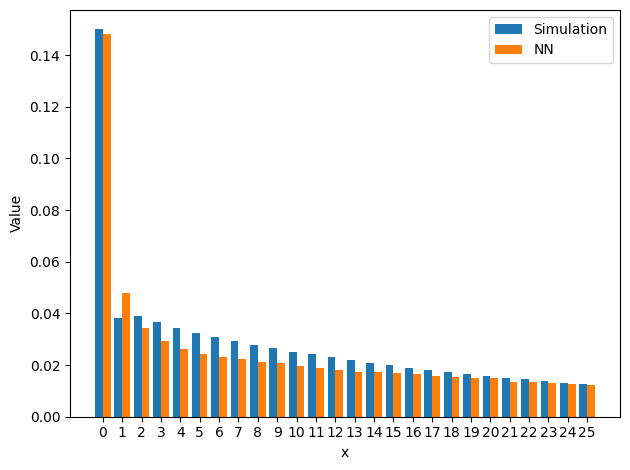

In [637]:
 # x values
x = np.arange(26)  # 0,1,...,20

# take first 21 values
y1 = label[:26]
y2 = L_dist_c[:26]

bar_width = 0.4

plt.figure()
plt.bar(x - bar_width / 2, y1, width=bar_width, label='Simulation')
plt.bar(x + bar_width / 2, y2, width=bar_width, label='NN')

plt.xlabel('x')
plt.ylabel('Value')
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()

In [638]:
SAE = np.abs(label[:100] - L_dist_c[:100]).sum()
EL_nn = (np.arange(L_dist_c.shape[0]) * L_dist_c).sum()
EL_sim = (np.arange(label.shape[0]) * label).sum()

error_nn = 100 * abs(EL_nn - EL_sim) / EL_sim
error_nn, SAE

np.float64(0.1769795461511316)

np.float64(47.830739724671275)

torch.Size([1, 18])

In [10]:
rho

0.8471638292568161

  0%|                                                                                               | 0/10 [00:00<?, ?it/s]

4
[1.]


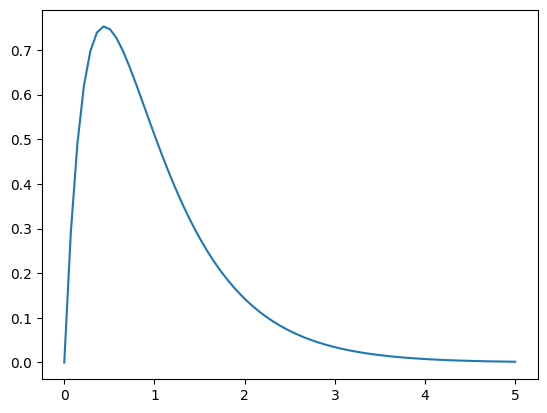

 10%|████████▋                                                                              | 1/10 [00:31<04:47, 31.96s/it]

5
[1.]


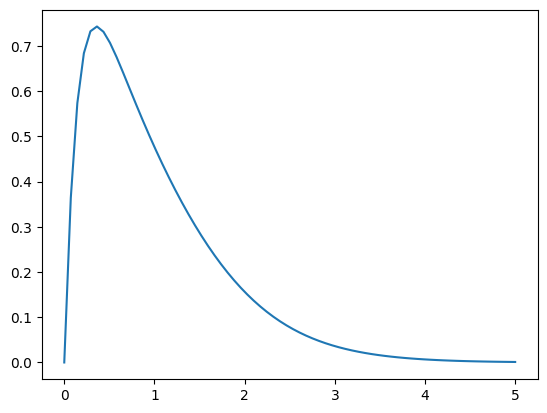

 20%|█████████████████▍                                                                     | 2/10 [01:13<04:59, 37.42s/it]

5
[1.]


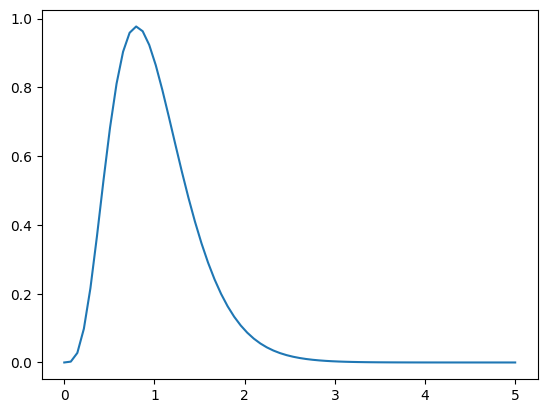

 30%|██████████████████████████                                                             | 3/10 [02:24<06:11, 53.08s/it]

3
[1.]


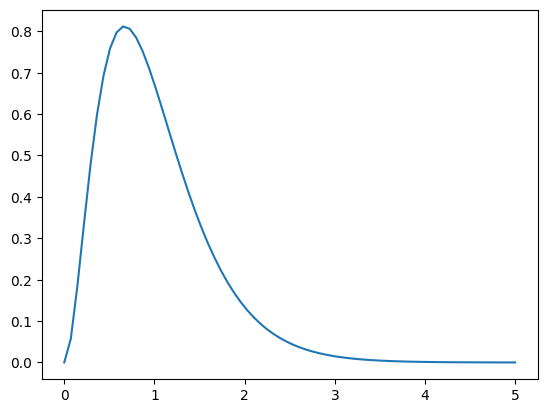

 40%|██████████████████████████████████▊                                                    | 4/10 [03:08<04:55, 49.30s/it]

3
[1.]


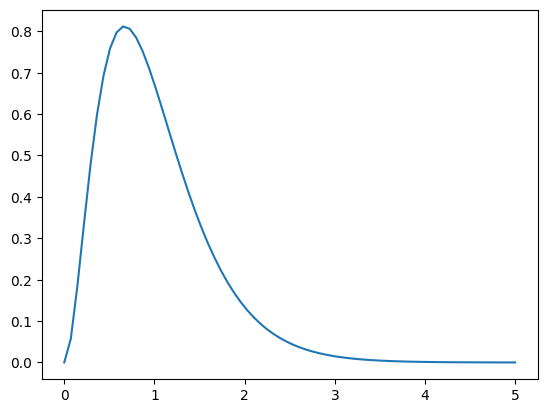

 50%|███████████████████████████████████████████▌                                           | 5/10 [03:48<03:50, 46.07s/it]

5
[1.]


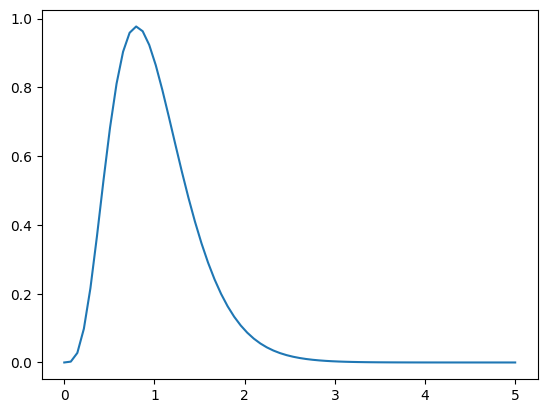

 50%|███████████████████████████████████████████▌                                           | 5/10 [03:54<03:54, 46.87s/it]


KeyboardInterrupt: 

In [123]:
hyp_orig = {}
hyp_trace = {}
for ind in tqdm(range(10)):
    if True:
        degree = np.random.randint(3,6)
        print(degree)
        dat = sample(degree)
        A = dat[1]
        x_vals = np.linspace(0,5,70)
        
        alpha = dat[0]
        print(compute_first_n_moments(alpha,A,1))
        
        y_vals = compute_pdf_within_range(x_vals, alpha, A)
        plt.figure()
        plt.plot(x_vals, y_vals)
        plt.show()
    
    
        hyp_trace[ind] = SamplesFromPH(ml.matrix(np.array(alpha).reshape(1,-1)), ml.matrix(np.array(A)), 1000000)
        hyp_orig[ind] = (alpha, A)
    # except:
    #     ind = ind -1

In [4]:
hyp_orig = {}
hyp_trace = {}
chosen_pathes = []
path = r'C:\Users\Eshel\workspace\data\ph_examples'
folds = os.listdir(path)
SCV_dict = {}
for ind in range(3):
    choose_fold = np.random.choice(folds)
    curr_path = os.path.join(path, choose_fold)
    files = os.listdir(curr_path)
    choose_file = np.random.choice(files)
    final_path = os.path.join(curr_path, choose_file)
    dat = pkl.load(open(final_path, 'rb'))
    hyp_trace[ind] = dat[-1]
    hyp_orig[ind] = (dat[0], dat[1])
    SCV_dict[ind] = dat[2][1]-1
    # print(final_path)
    chosen_pathes.append(final_path)

In [5]:
num_streams = 2
arrivals = {}
for stream in range(num_streams):
    arrivals[stream] = hyp_trace[0]

services = hyp_trace[1]

In [133]:
np.random.randint(4)

0

In [22]:
num_streams = 2
num_stations = 2
arrivals = {}
services = {}
for station in ['a', 'b']:
    for stream in range(num_streams):
        arrivals[(station, stream)] = hyp_trace[0]

    services[station] = hyp_trace[1]

services['c'] = hyp_trace[2]

In [23]:
a = 3
arrivals[('a', 0)] = arrivals[('a', 0)]*a
arrivals[('a', 1)] = arrivals[('a', 1)]*(a/(a-1))

mom1_arrival_a = 1/(1/(arrivals['a', 0]).mean()+ 1/(arrivals[('a',1)]).mean())
lama  = 1/mom1_arrival_a
lama

np.float64(1.000436279878989)

In [15]:
arrivals[('a', 0)].mean(), arrivals[('a', 1)].mean()

(np.float64(0.9995639103781412), np.float64(0.9995639103781412))

In [60]:
a = 3
arrivals[('b', 0)] = arrivals[('b', 0)]*a
arrivals[('b', 1)] = arrivals[('b', 1)]*(a/(a-1))

mom1_arrival_b = 1/(1/(arrivals[('b', 0)]).mean()+ 1/(arrivals[('b',1)]).mean())
lamb  = 1/mom1_arrival_b
lamb

np.float64(1.000436279878989)

In [24]:
(arrivals[('a',0)]).mean()/(arrivals[('a',1)]).mean()

np.float64(2.0)

In [27]:
1/(arrivals[('a',0)]).mean() +1/(arrivals[('a',1)]).mean()

np.float64(1.000436279878989)

In [41]:
rhoa = 0.85
meansera = rhoa/ lama
lama*meansera, rhoa

(np.float64(0.85), 0.85)

In [75]:
lamb

np.float64(1.0000239949945229)

In [47]:
rhob = 0.85
meanserb = rhob/ lama
lamb*meanserb, rhob

(np.float64(0.4722222222222214), 0.85)

In [25]:
lama, meansera, mom1_arrival_a, lamb, meanserb, mom1_arrival_b

(np.float64(1.0000239949945229),
 np.float64(0.8499796047440396),
 np.float64(0.999976005581223),
 np.float64(1.0000239949945229),
 np.float64(0.8499796047440396),
 np.float64(0.999976005581223))

In [155]:
services_normsa.mean()

np.float64(0.8514083385334856)

In [42]:
services_normsa = services['a']*meansera

ser_moms_normalized = {}



In [43]:
ser_moms_normalized = {}


In [44]:
ser_moms_normalized['a'] = []

for mom in range(1,6):
    ser_moms_normalized['a'].append((services_normsa**mom).mean())

ser_moms_normalized['a']

[np.float64(0.8497387883971259),
 np.float64(3.0283981336100343),
 np.float64(22.465368944207732),
 np.float64(245.70007941144365),
 np.float64(3445.8037814350237)]

{'a': [np.float64(0.8510328802759657),
  np.float64(1.1384416305901306),
  np.float64(2.0379055977496714),
  np.float64(4.501637568356067),
  np.float64(11.721227888733768)],
 'b': [np.float64(0.8510328802759657),
  np.float64(1.1384416305901306),
  np.float64(2.0379055977496714),
  np.float64(4.501637568356067),
  np.float64(11.721227888733768)]}

In [49]:
ser_moms_normalized['b']

[np.float64(0.8497387883971259),
 np.float64(3.0283981336100343),
 np.float64(22.465368944207732),
 np.float64(245.70007941144365),
 np.float64(3445.8037814350237)]

In [74]:
meanserb

np.float64(0.8499796047440396)

In [48]:
services_normsb = services['b']*meanserb

ser_moms_normalized['b'] = []

for mom in range(1,6):
    ser_moms_normalized['b'].append((services_normsb**mom).mean())

ser_moms_normalized['b']

[np.float64(0.8497387883971259),
 np.float64(3.0283981336100343),
 np.float64(22.465368944207732),
 np.float64(245.70007941144365),
 np.float64(3445.8037814350237)]

In [160]:
ser_moms_normalized['a']

[np.float64(0.8510328802759657),
 np.float64(1.1384416305901306),
 np.float64(2.0379055977496714),
 np.float64(4.501637568356067),
 np.float64(11.721227888733768)]

In [29]:
arrival_a_1_station_a

array([9.78873580e-06, 2.24383150e-03, 5.57804476e-05, 1.43918093e-03,
       5.31563698e-05, 0.00000000e+00, 5.71715700e-02, 5.67178300e-01,
       6.45620816e-02, 0.00000000e+00, 5.27894058e-09, 0.00000000e+00,
       9.20504563e-02, 0.00000000e+00, 1.80146919e-02, 0.00000000e+00,
       1.97221157e-01, 0.00000000e+00, 0.00000000e+00])

In [28]:
arrival_a_1_station_a, arrival_A_1_station_a = hyp_orig[0]
arrival_a_2_station_a, arrival_A_2_station_a = hyp_orig[0]

In [30]:
arrival_a_1_station_b, arrival_A_1_station_b = hyp_orig[0]
arrival_a_2_station_b, arrival_A_2_station_b = hyp_orig[0]

In [31]:
arrival_A_1_station_a = arrival_A_1_station_a/a
arrival_A_2_station_a = arrival_A_2_station_a/(a/(a-1))
arrival_A_2_station_a

array([[  -4.43091463,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ],
       [   1.76058309,   -4.60358794,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,   -2.30409635,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ],
       [   0.        ,

In [32]:
arrival_A_1_station_b = arrival_A_1_station_b/a
arrival_A_2_station_b = arrival_A_2_station_b/(a/(a-1))
arrival_A_2_station_b

array([[  -4.43091463,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ],
       [   1.76058309,   -4.60358794,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ],
       [   0.        ,    0.        ,   -2.30409635,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ],
       [   0.        ,

In [35]:
arrivals[('b',0)].mean()

np.float64(0.9999760055812206)

In [50]:
services_norms = {}
services_norms['a'] = services_normsa
services_norms['b'] = services_normsb

In [51]:
services_norms['c'] = services['c']*0.2
services_norms['c'].mean()

np.float64(0.20002576760774177)

In [52]:
services_norms['c'].shape

(40000000,)

In [62]:
1/arrivals[('a', 0)].mean() +1/ arrivals[('a', 1)].mean(), services_norms['a'].mean()

(np.float64(1.0000239949945229), np.float64(0.8499047231194387))

In [78]:
1/arrivals[('b', 0)].mean() +1/ arrivals[('b', 1)].mean(), services_norms['b'].mean()

(np.float64(1.0000239949945229), np.float64(0.8499047231194387))

In [64]:
1/arrivals[('a', 0)].mean() + 1/arrivals[('a', 1)].mean()+ 1/arrivals[('b', 0)].mean()+ 1/arrivals[('b', 1)].mean()

np.float64(3.000071984983574)

In [53]:
services_norms['c'].mean()

np.float64(0.20002576760774177)

In [54]:
ser_moms_normalized['c'] = []

for mom in range(1,6):
    ser_moms_normalized['c'].append((services_norms['c']**mom).mean())
ser_moms_normalized

{'a': [np.float64(0.8497387883971259),
  np.float64(3.0283981336100343),
  np.float64(22.465368944207732),
  np.float64(245.70007941144365),
  np.float64(3445.8037814350237)],
 'b': [np.float64(0.8497387883971259),
  np.float64(3.0283981336100343),
  np.float64(22.465368944207732),
  np.float64(245.70007941144365),
  np.float64(3445.8037814350237)],
 'c': [np.float64(0.20002576760774177),
  np.float64(0.16780850759187624),
  np.float64(0.29303200930873036),
  np.float64(0.754409775273715),
  np.float64(2.490537332804923)]}

In [79]:
arrivals[('a', 0)].mean(), arrivals[('a', 1)].mean(), arrivals[('b', 0)].mean(), arrivals[('b', 1)].mean()

(np.float64(2.999928016743669),
 np.float64(1.4999640083718344),
 np.float64(2.999928016743669),
 np.float64(1.4999640083718344))

In [80]:
1/arrivals[('a', 0)].mean()+ 1/ arrivals[('a', 1)].mean() +1/ arrivals[('b', 0)].mean() +1/ arrivals[('b', 1)].mean()

np.float64(2.0000479899890458)

In [57]:
(1/arrivals[('a', 0)].mean()+ 1/ arrivals[('a', 1)].mean())*services_norms['a'].mean()

np.float64(0.8501095123329)

In [59]:
1/arrivals[('b', 0)].mean()+ 1/ arrivals[('b', 1)].mean()

np.float64(2.0008725597579726)

In [61]:
(1/arrivals[('b', 0)].mean()+ 1/ arrivals[('b', 1)].mean())*services_norms['b'].mean()

np.float64(0.8501095123329)

In [83]:
3*services_norms['c'].mean()

np.float64(0.6000773028232254)

In [35]:
arrivals.keys()

dict_keys([('a', 0), ('a', 1), ('b', 0), ('b', 1)])

In [38]:
arrivals[('a', 0)].mean(), arrivals[('a', 1)].mean()

(np.float64(2.9986917311344152), np.float64(1.4993458655672076))

In [62]:
sim_time = 95000

queue_example1 = Queue_n_streams_2_tiers(arrivals, services_norms, num_streams,sim_time)
queue_example1.run()

L_dist_a = queue_example1.num_cust_durations['a']/queue_example1.num_cust_durations['a'].sum()
L_dist_a[:15]

In [63]:
L_dist_a = queue_example1.num_cust_durations['a']/queue_example1.num_cust_durations['a'].sum()
L_dist_a[:15]

array([0.1440714 , 0.05415748, 0.04609602, 0.04028673, 0.03918217,
       0.03538553, 0.03307858, 0.03209743, 0.03015176, 0.02772841,
       0.02675004, 0.02505577, 0.02332857, 0.02309283, 0.02180273])

In [64]:
L_dist_b = queue_example1.num_cust_durations['b']/queue_example1.num_cust_durations['b'].sum()
L_dist_b[:15]

array([0.1440714 , 0.05415748, 0.04609602, 0.04028673, 0.03918217,
       0.03538553, 0.03307858, 0.03209743, 0.03015176, 0.02772841,
       0.02675004, 0.02505577, 0.02332857, 0.02309283, 0.02180273])

In [1052]:
L_dist_c = queue_example1.num_cust_durations['c']/queue_example1.num_cust_durations['c'].sum()
L_dist_c[:15]

array([0.24713735, 0.16512012, 0.11762661, 0.08988659, 0.07024025,
       0.05535631, 0.04522115, 0.03666124, 0.02997703, 0.02474854,
       0.02033764, 0.01705438, 0.0138699 , 0.01159307, 0.00986772])

In [66]:
ser_torch_a =  torch.tensor(np.array(ser_moms_normalized['a']), dtype=torch.float32)
ser_torch_a = ser_torch_a.to(device)
ser_torch_a = ser_torch_a.reshape(1,-1)
ser_torch_a = torch.log(ser_torch_a)
torch.exp(ser_torch_a)

tensor([[8.4974e-01, 3.0284e+00, 2.2465e+01, 2.4570e+02, 3.4458e+03]],
       device='cuda:0')

In [67]:
ser_torch_b =  torch.tensor(np.array(ser_moms_normalized['b']), dtype=torch.float32)
ser_torch_b = ser_torch_b.to(device)
ser_torch_b = ser_torch_b.reshape(1,-1)
ser_torch_b = torch.log(ser_torch_b)
torch.exp(ser_torch_b)

tensor([[8.4974e-01, 3.0284e+00, 2.2465e+01, 2.4570e+02, 3.4458e+03]],
       device='cuda:0')

### 1. Compute moments and auto-correlations from MAP
### 2. Create input for NN that merges
### 3. Compute moments and auto-correlations for the merges process
### 4. Scale the new the process to have mom1 = 1
### 5. Insert the processed input into a NN for steady-state og a G/GI/1
### 6. Compare it into simulation and create a graph

In [70]:
a/(a-1)

1.5

In [68]:
arrival_A_2_new_station_a = arrival_A_2_station_a*(a/(a-1))
arrival_A_1_new_station_a = arrival_A_1_station_a*(a/(a-1)) 
compute_first_n_moments(arrival_a_2_station_a, arrival_A_2_new_station_a,1) , compute_first_n_moments(arrival_a_1_station_a, arrival_A_1_new_station_a,1) 

([array([1.])], [array([2.])])

In [69]:
arrival_A_2_new_station_b = arrival_A_2_station_b*(a/(a-1))
arrival_A_1_new_station_b = arrival_A_1_station_b*(a/(a-1)) 
compute_first_n_moments(arrival_a_2_station_b, arrival_A_2_new_station_b,1) , compute_first_n_moments(arrival_a_1_station_b, arrival_A_1_new_station_b,1) 

([array([1.])], [array([2.])])

In [71]:
# step 1

ind1 = 0
ind2 = 1
D0a_station_a, D1a_station_a = ph_to_map_renewal(arrival_a_1_station_a, arrival_A_1_new_station_a )
D0b_station_a, D1b_station_a = ph_to_map_renewal(arrival_a_2_station_a, arrival_A_2_new_station_a )

In [72]:
# step 2

resa_station_a = create_mom_cor_vector(D0a_station_a.copy(), D1a_station_a.copy())
resb_station_a = create_mom_cor_vector(D0b_station_a.copy(), D1b_station_a.copy())

In [73]:
resa_station_a[0], resb_station_a[0]

(np.float64(2.000000000000001), np.float64(1.0000000000000004))

In [74]:
# step 1

ind1 = 0
ind2 = 1
D0a_station_b, D1a_station_b = ph_to_map_renewal(arrival_a_1_station_b, arrival_A_1_new_station_b )
D0b_station_b, D1b_station_b = ph_to_map_renewal(arrival_a_2_station_b, arrival_A_2_new_station_b )

In [75]:
# step 2

resa_station_b = create_mom_cor_vector(D0a_station_b.copy(), D1a_station_b.copy())
resb_station_b = create_mom_cor_vector(D0b_station_b.copy(), D1b_station_b.copy())

In [154]:
resa[0]

np.float64(3.0)

In [76]:
# step 2 cont'
max_lag = 2
max_power_1 = 2
max_power_2 = 2
num_arrive_moms = 5
df = pd.DataFrame([])

for corr_leg in range(1, 6):
    for mom_1 in range(1, 6):
        for mom_2 in range(1, 6):
            curr_ind = df.shape[0]
            df.loc[curr_ind, 'lag'] = corr_leg
            df.loc[curr_ind, 'mom_1'] = mom_1
            df.loc[curr_ind, 'mom_2'] = mom_2
            df.loc[curr_ind, 'index'] = curr_ind + 10


In [77]:

inp1_moms_station_a = resa_station_a[:num_arrive_moms]
inp2_moms_station_a = resb_station_a[:num_arrive_moms]

inp1_corrs_station_a = resa_station_a[df.loc[(df['lag']<=max_lag)&(df['mom_1']<=max_power_1)&(df['mom_2']<=max_power_2),:].index+10]
inp2_corrs_station_a = resb_station_a[df.loc[(df['lag']<=max_lag)&(df['mom_1']<=max_power_1)&(df['mom_2']<=max_power_2),:].index+10]


tot_inp_station_a = np.concatenate((np.log(inp1_moms_station_a),  inp1_corrs_station_a, np.log(inp2_moms_station_a),inp2_corrs_station_a))
tot_inp_station_a = torch.tensor(tot_inp_station_a, dtype=torch.float32)

tot_inp_station_a.shape

torch.Size([26])

In [78]:

inp1_moms_station_b = resa_station_b[:num_arrive_moms]
inp2_moms_station_b = resb_station_b[:num_arrive_moms]

inp1_corrs_station_b = resa_station_a[df.loc[(df['lag']<=max_lag)&(df['mom_1']<=max_power_1)&(df['mom_2']<=max_power_2),:].index+10]
inp2_corrs_station_b = resb_station_a[df.loc[(df['lag']<=max_lag)&(df['mom_1']<=max_power_1)&(df['mom_2']<=max_power_2),:].index+10]


tot_inp_station_b = np.concatenate((np.log(inp1_moms_station_b),  inp1_corrs_station_b, np.log(inp2_moms_station_b),inp2_corrs_station_b))
tot_inp_station_b = torch.tensor(tot_inp_station_b, dtype=torch.float32)

tot_inp_station_b.shape

torch.Size([26])

In [79]:
# step 3
import torch.nn.functional as F
import torch.nn as nn
class Net_moms(nn.Module):

    def __init__(self, input_size, output_size):
        
        super().__init__()
        
        self.fc1 = nn.Linear(input_size , 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, output_size)


    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x  


class Net_corrs(nn.Module):

    def __init__(self, input_size, output_size):
        
        super().__init__()
        
        self.fc1 = nn.Linear(input_size , 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, output_size)


    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x  

In [80]:

input_size_moms ,output_size_moms = 26, 4

net_moms = Net_moms(input_size_moms,output_size_moms).to(device)

input_size_corrs,output_size_corrs = 26, 8

net_corrs = Net_corrs(input_size_corrs,output_size_corrs).to(device)

In [81]:
model_path = r'C:\Users\Eshel\workspace\MAP\models'
file_name_model_corrs = 'merge_corrs_1.pkl'
file_name_model_moms = 'merge_moments_1.pkl'

net_moms.load_state_dict(torch.load(os.path.join(model_path, file_name_model_moms)))
net_corrs.load_state_dict(torch.load(os.path.join(model_path, file_name_model_corrs)))

C:\Users\Eshel\AppData\Local\Temp\ipykernel_18628\2982052168.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_moms.load_state_dict(torch.load(os.path.join(model_path,

<All keys matched successfully>

In [82]:
## Get pred moms:

moms_pred_station_a = net_moms(tot_inp_station_a.reshape(1,-1).to(device))
corrs_pred_station_a = net_corrs(tot_inp_station_a.reshape(1,-1).to(device))

moms_pred_station_a, corrs_pred_station_a

(tensor([[0.5019, 1.9678, 3.7370, 5.7557]], device='cuda:0',
        grad_fn=<AddmmBackward0>),
 tensor([[-0.0267, -0.0149, -0.0155, -0.0082,  0.0562,  0.0229,  0.0229,  0.0105]],
        device='cuda:0', grad_fn=<AddmmBackward0>))

In [83]:
## Get pred moms:

moms_pred_station_b = net_moms(tot_inp_station_b.reshape(1,-1).to(device))
corrs_pred_station_b = net_corrs(tot_inp_station_b.reshape(1,-1).to(device))

moms_pred_station_b, corrs_pred_station_b

(tensor([[0.5019, 1.9678, 3.7370, 5.7557]], device='cuda:0',
        grad_fn=<AddmmBackward0>),
 tensor([[-0.0267, -0.0149, -0.0155, -0.0082,  0.0562,  0.0229,  0.0229,  0.0105]],
        device='cuda:0', grad_fn=<AddmmBackward0>))

In [109]:
torch.exp(moms_pred_station_a)

tensor([[1.0086, 1.8275, 3.5576, 7.4001]], device='cuda:0',
       grad_fn=<ExpBackward0>)

In [84]:
moms_scaled_station_a = 1/(1/torch.exp(tot_inp_station_a[0]) + 1/torch.exp(tot_inp_station_a[13]))
moms_scaled_station_a

tensor(0.6667)

In [89]:
moms_scaled_station_a = 1/(1/torch.exp(tot_inp_station_a[0]) + 1/torch.exp(tot_inp_station_a[13]))

moms_station_a = [1]

for mom in range(1,5):
    print(mom+1)
    moms_station_a.append(torch.exp(moms_pred_station_a[0,mom-1])/(moms_scaled_station_a**(mom+1)))

moms_agg_station_a = torch.log(torch.tensor(moms_station_a).to(device))


2
3
4
5


In [86]:
moms_scaled_station_b = 1/(1/torch.exp(tot_inp_station_b[0]) + 1/torch.exp(tot_inp_station_b[13]))

moms_station_b = [1]

for mom in range(1,5):
    print(mom+1)
    moms_station_b.append(torch.exp(moms_pred_station_b[0,mom-1])/(moms_scaled_station_b**(mom+1)))

moms_agg_station_b = torch.log(torch.tensor(moms_station_b).to(device))


2
3
4
5


In [90]:
torch.exp(moms_agg_station_a)

tensor([1.0000e+00, 3.7165e+00, 2.4148e+01, 2.1247e+02, 2.3996e+03],
       device='cuda:0')

In [87]:
torch.exp(moms_agg_station_b)

tensor([1.0000e+00, 3.7165e+00, 2.4148e+01, 2.1247e+02, 2.3996e+03],
       device='cuda:0')

In [99]:
inp_g_gi_1_station_a = torch.concatenate((moms_agg_station_a, corrs_pred_station_a.flatten())).reshape(1,-1)
inp_g_gi_1_station_a

tensor([[ 0.0000,  1.3128,  3.1842,  5.3588,  7.7831, -0.0267, -0.0149, -0.0155,
         -0.0082,  0.0562,  0.0229,  0.0229,  0.0105]], device='cuda:0',
       grad_fn=<ViewBackward0>)

In [100]:
inp_g_gi_1_station_b = torch.concatenate((moms_agg_station_b, corrs_pred_station_b.flatten())).reshape(1,-1)
inp_g_gi_1_station_b

tensor([[ 0.0000,  1.3128,  3.1842,  5.3588,  7.7831, -0.0267, -0.0149, -0.0155,
         -0.0082,  0.0562,  0.0229,  0.0229,  0.0105]], device='cuda:0',
       grad_fn=<ViewBackward0>)

In [202]:
meansera

np.float64(0.8500554656814763)

In [204]:
services_norms['a']

array([0.96245528, 0.78145431, 0.15160505, ..., 0.35172075, 0.13450084,
       1.22055824])

In [ ]:
# services_norms2 = services_norms*meanser
# services_norms.mean()

# ser_moms_normalized = []

# for mom in range(1,6):
#     ser_moms_normalized.append((services_norms2**mom).mean())

# ser_moms_normalized

In [91]:
class Net_steady_1(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 200)
        self.fc4 = nn.Linear(200, 350)
        self.fc5 = nn.Linear(350, 600)
        self.fc6 = nn.Linear(600, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = self.fc6(x)
        return x

In [92]:
input_size_steady_1 = 18
output_size_steady_1 = 1499

In [93]:
model_path_steady_1 = r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\steady_1'
models_steady_1 =  os.listdir(model_path_steady_1)


full_path_steady_1 = os.path.join(model_path_steady_1, models_steady_1[0])


In [94]:
net_steady_1 = Net_steady_1(input_size_steady_1, output_size_steady_1).to(device)
net_steady_1.load_state_dict(torch.load(full_path_steady_1))


C:\Users\Eshel\AppData\Local\Temp\ipykernel_18628\3948726535.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_steady_1.load_state_dict(torch.load(full_path_steady_1))

<All keys matched successfully>

In [121]:
torch.exp(ser_torch_a)

tensor([[8.4990e-01, 3.2979e+00, 2.4051e+01, 2.4402e+02, 3.1219e+03]],
       device='cuda:0')

In [101]:
input_steady_1_station_a = torch.concatenate((inp_g_gi_1_station_a,ser_torch_a), axis = 1)
input_steady_1_station_b = torch.concatenate((inp_g_gi_1_station_b,ser_torch_b), axis = 1)

In [102]:
m = nn.Softmax(dim=1)
# input_steady_1 = inp_g_gi_1

probs_steady_1_station_a = net_steady_1(input_steady_1_station_a)
normalizing_const_station_a = torch.exp(input_steady_1_station_a[0,-5])
probs_steady_1_station_a = m(probs_steady_1_station_a)
probs_steady_1_station_a  = probs_steady_1_station_a*normalizing_const_station_a

probs_steady_1_station_a = probs_steady_1_station_a.to('cpu')
probs_steady_1_station_a = torch.concatenate((torch.tensor([[1-normalizing_const_station_a]]),probs_steady_1_station_a[0:1,:]), axis = 1)
probs_steady_1_station_a.shape

torch.Size([1, 1500])

In [103]:
m = nn.Softmax(dim=1)
# input_steady_1 = inp_g_gi_1

probs_steady_1_station_b = net_steady_1(input_steady_1_station_b)
normalizing_const_station_b = torch.exp(input_steady_1_station_b[0,-5])
probs_steady_1_station_b = m(probs_steady_1_station_b)
probs_steady_1_station_b  = probs_steady_1_station_b*normalizing_const_station_b

probs_steady_1_station_b = probs_steady_1_station_b.to('cpu')
probs_steady_1_station_b = torch.concatenate((torch.tensor([[1-normalizing_const_station_b]]),probs_steady_1_station_b[0:1,:]), axis = 1)
probs_steady_1_station_b.shape

torch.Size([1, 1500])

In [104]:
with torch.no_grad():
    label_station_a = probs_steady_1_station_a.cpu().numpy().flatten()
    label_station_b = probs_steady_1_station_b.cpu().numpy().flatten()

In [105]:
label_station_a.shape

(1500,)

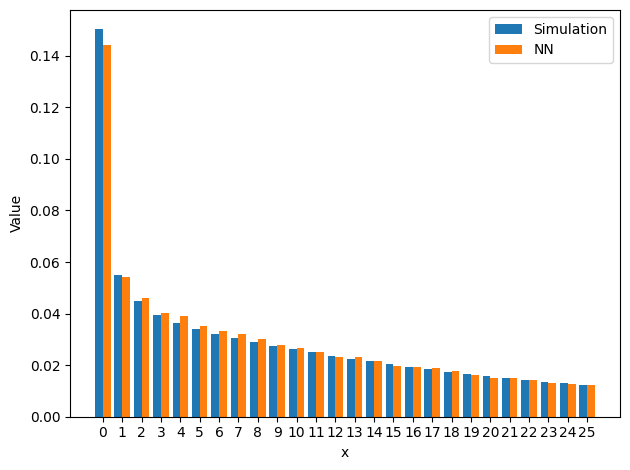

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# x values
x = np.arange(26)  # 0,1,...,20

# take first 21 values
y1 = label_station_a[:26]
y2 = L_dist_a[:26]

bar_width = 0.4

plt.figure()
plt.bar(x - bar_width/2, y1, width=bar_width, label='Simulation')
plt.bar(x + bar_width/2, y2, width=bar_width, label='NN')

plt.xlabel('x')
plt.ylabel('Value')
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()


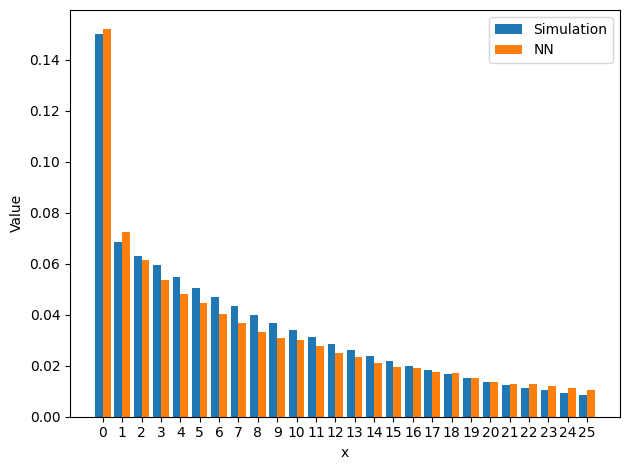

In [127]:
import numpy as np
import matplotlib.pyplot as plt

# x values
x = np.arange(26)  # 0,1,...,20

# take first 21 values
y1 = label_station_b[:26]
y2 = L_dist_b[:26]

bar_width = 0.4

plt.figure()
plt.bar(x - bar_width/2, y1, width=bar_width, label='Simulation')
plt.bar(x + bar_width/2, y2, width=bar_width, label='NN')

plt.xlabel('x')
plt.ylabel('Value')
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()


### 1. Compute inter departure from station a and station b
### 2. Normalize such that the mean inter-arrival from station b is exactly 1 - perheps it is already the case. 
### 3. Compute merged inter-arrival to station c
### 4. Normalize inter-arrival and service to station c such that inter-arrival is with mean 1
### 5. Compute steady_state station c
### 6. Compare station c probs: sim vs. nn 

In [107]:
class Net_depart_1_moms(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x


class Net_depart_1_corrs(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x



model_path_depart_1_moms = r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\depart_1_moms'
model_path_depart_1_cors = r'C:\Users\Eshel\workspace\Tandem_queueing_ML\models\depart_1_cors'



models_depart_1_moms =  os.listdir(model_path_depart_1_moms)
models_depart_1_cors =  os.listdir(model_path_depart_1_cors)

full_path_depart_1_moms = os.path.join(model_path_depart_1_moms, models_depart_1_moms[0])
full_path_depart_1_cors = os.path.join(model_path_depart_1_cors, models_depart_1_cors[0])


input_size_depart_1_moms = 18
output_size_depart_1_moms = 5
net_depart_1_moms = Net_depart_1_moms(input_size_depart_1_moms, output_size_depart_1_moms).to(device)
net_depart_1_moms.load_state_dict(torch.load(full_path_depart_1_moms))

# print(net_depart_1_moms)

input_size_depart_1_corrs = 18
output_size_depart_1_corrs = 8
net_depart_1_corrs = Net_depart_1_corrs(input_size_depart_1_corrs, output_size_depart_1_corrs).to(device)
net_depart_1_corrs.load_state_dict(torch.load(full_path_depart_1_cors))

C:\Users\Eshel\AppData\Local\Temp\ipykernel_18628\2713257258.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_depart_1_moms.load_state_dict(torch.load(full_path_depa

<All keys matched successfully>

In [117]:
torch.exp(input_steady_1_station_a)[0][-5:]

tensor([8.4974e-01, 3.0284e+00, 2.2465e+01, 2.4570e+02, 3.4458e+03],
       device='cuda:0', grad_fn=<SliceBackward0>)

In [109]:
depart_moms_station_a = net_depart_1_moms(input_steady_1_station_a)
depart_moms_station_b = net_depart_1_moms(input_steady_1_station_b)

depart_corrs_station_a = net_depart_1_corrs(input_steady_1_station_a)
depart_corrs_station_b = net_depart_1_corrs(input_steady_1_station_b)




In [110]:
inp_stream_a = torch.concatenate((depart_moms_station_a, depart_corrs_station_a),axis = 1)
inp_stream_b = torch.concatenate((depart_moms_station_b, depart_corrs_station_b),axis = 1)

inp_merging_station_c = torch.concatenate((inp_stream_a, inp_stream_b),axis = 1)
inp_merging_station_c

tensor([[-4.0609e-39,  1.3576e+00,  3.4084e+00,  5.7860e+00,  8.3979e+00,
          8.0268e-03,  3.2787e-03,  5.3610e-03,  1.9466e-03,  7.9300e-03,
          3.8157e-03,  3.7292e-03,  2.2271e-03, -4.0609e-39,  1.3576e+00,
          3.4084e+00,  5.7860e+00,  8.3979e+00,  8.0268e-03,  3.2787e-03,
          5.3610e-03,  1.9466e-03,  7.9300e-03,  3.8157e-03,  3.7292e-03,
          2.2271e-03]], device='cuda:0', grad_fn=<CatBackward0>)

In [112]:
moms_pred_station_c = net_moms(inp_merging_station_c.to(device))
corrs_pred_station_c = net_corrs(inp_merging_station_c.to(device))

moms_pred_station_c, corrs_pred_station_c

(tensor([[-0.2151,  0.9618,  2.5657,  4.4740]], device='cuda:0',
        grad_fn=<AddmmBackward0>),
 tensor([[0.0518, 0.0304, 0.0299, 0.0181, 0.0308, 0.0178, 0.0179, 0.0127]],
        device='cuda:0', grad_fn=<AddmmBackward0>))

In [252]:
depart_moms_station_a

tensor([[-1.5551e-39,  6.4867e-01,  1.6859e+00,  2.9778e+00,  4.4538e+00]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

tensor(0.5000, device='cuda:0', grad_fn=<MulBackward0>)

In [134]:
mom1_station_c = 1/(1/torch.exp(input_steady_1_station_b[0,0]) + 1/torch.exp(depart_moms_station_b[0,0]))
mom1_station_c_tensor = torch.tensor([mom1_station_c]).reshape(1,-1).to(device)

In [135]:
torch.exp(moms_pred_station_c)

tensor([[ 0.8404,  2.6764, 12.4904, 76.3924]], device='cuda:0',
       grad_fn=<ExpBackward0>)

In [136]:
1/torch.exp(depart_moms_station_a[0])

tensor([1.0000e+00, 2.5741e-01, 3.6617e-02, 3.6980e-03, 3.0753e-04],
       device='cuda:0', grad_fn=<MulBackward0>)

In [137]:
moms_to_station_c = torch.concatenate((torch.log(mom1_station_c_tensor), moms_pred_station_c),axis =1)
torch.exp(moms_to_station_c)

tensor([[ 0.5000,  0.8404,  2.6764, 12.4904, 76.3924]], device='cuda:0',
       grad_fn=<ExpBackward0>)

In [138]:
torch.exp(moms_to_station_c)[0,0]


tensor(0.5000, device='cuda:0', grad_fn=<SelectBackward0>)

In [139]:
ser_moms_normalized['c']

[np.float64(0.20002576760774177),
 np.float64(0.16780850759187624),
 np.float64(0.29303200930873036),
 np.float64(0.754409775273715),
 np.float64(2.490537332804923)]

In [285]:
torch.exp(moms_to_station_c)[0,0]

tensor(0.5000, device='cuda:0', grad_fn=<SelectBackward0>)

In [145]:
with torch.no_grad():
    services_c = services_norms['c']/torch.exp(moms_to_station_c)[0,0].cpu().numpy()


moms_scaled_station_c = torch.exp(moms_to_station_c)[0,0]


moms_station_c = [1]

for mom in range(1,5):
    print(mom+1)
    moms_station_c.append(torch.exp(moms_to_station_c[0,mom])/(moms_scaled_station_c**(mom+1)))

moms_agg_station_c = torch.log(torch.tensor(moms_station_c).to(device))
moms_agg_station_c

np.float64(0.40005153521548353)

2
3
4
5


tensor([0.0000, 1.2124, 3.0639, 5.2976, 7.8016], device='cuda:0')

In [147]:
torch.exp(moms_agg_station_c), moms_agg_station_c

(tensor([1.0000e+00, 3.3615e+00, 2.1412e+01, 1.9985e+02, 2.4446e+03],
        device='cuda:0'),
 tensor([0.0000, 1.2124, 3.0639, 5.2976, 7.8016], device='cuda:0'))

In [148]:
ser_c_moms = []
for mom in range(5):
    ser_c_moms.append((services_c**(mom+1)).mean())
ser_c_moms

[np.float64(0.40005153521548353),
 np.float64(0.671234030367505),
 np.float64(2.344256074469843),
 np.float64(12.07055640437944),
 np.float64(79.69719464975753)]

In [149]:
ser_c_moms = torch.tensor(ser_c_moms).to(device)

In [304]:
moms_agg_station_c, corrs_pred_station_c, ser_c_moms

(tensor([0.0000, 0.6648, 1.7289, 3.0557, 4.5870], device='cuda:0'),
 tensor([[-0.0159, -0.0112, -0.0118, -0.0085, -0.0228, -0.0138, -0.0138, -0.0088]],
        device='cuda:0', grad_fn=<AddmmBackward0>),
 tensor([ 0.7998,  1.2785,  3.0631,  9.7783, 39.0026], device='cuda:0',
        dtype=torch.float64))

In [150]:
inp_steady_1_station_c = torch.concatenate((moms_agg_station_c, corrs_pred_station_c.flatten(), torch.log(ser_c_moms))).reshape(1,-1)

inp_steady_1_station_c = torch.tensor(inp_steady_1_station_c, dtype=torch.float32)

C:\Users\Eshel\AppData\Local\Temp\ipykernel_41600\3019519464.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inp_steady_1_station_c = torch.tensor(inp_steady_1_station_c, dtype=torch.float32)


In [151]:
moms_agg_station_c, ser_c_moms

(tensor([0.0000, 1.2124, 3.0639, 5.2976, 7.8016], device='cuda:0'),
 tensor([ 0.4001,  0.6712,  2.3443, 12.0706, 79.6972], device='cuda:0',
        dtype=torch.float64))

In [152]:
torch.exp(inp_steady_1_station_c)

tensor([[1.0000e+00, 3.3615e+00, 2.1412e+01, 1.9985e+02, 2.4446e+03, 1.0291e+00,
         1.0177e+00, 1.0170e+00, 1.0108e+00, 1.0118e+00, 1.0065e+00, 1.0065e+00,
         1.0053e+00, 4.0005e-01, 6.7123e-01, 2.3443e+00, 1.2071e+01, 7.9697e+01]],
       device='cuda:0')

In [153]:
m = nn.Softmax(dim=1)
# input_steady_1 = inp_g_gi_1

probs_steady_1_station_c = net_steady_1(inp_steady_1_station_c)
normalizing_const_station_c = torch.exp(inp_steady_1_station_c[0,-5])
probs_steady_1_station_c = m(probs_steady_1_station_c)
probs_steady_1_station_c  = probs_steady_1_station_c*normalizing_const_station_c

probs_steady_1_station_c = probs_steady_1_station_c.to('cpu')
probs_steady_1_station_c = torch.concatenate((torch.tensor([[1-normalizing_const_station_c]]),probs_steady_1_station_c[0:1,:]), axis = 1)
probs_steady_1_station_c.shape

torch.Size([1, 1500])

tensor([[2.0021e-01, 1.6774e-01, 1.3714e-01,  ..., 7.3515e-09, 7.3521e-09,
         7.3525e-09]], grad_fn=<CatBackward0>)

In [154]:
with torch.no_grad():
    label_station_c = probs_steady_1_station_c.cpu().numpy().flatten()


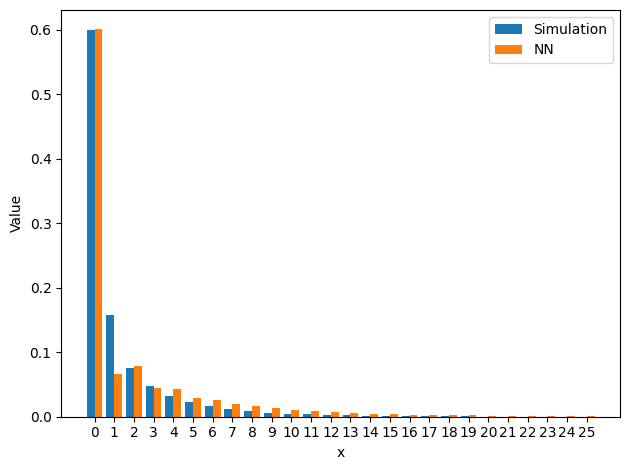

In [155]:
import numpy as np
import matplotlib.pyplot as plt

# x values
x = np.arange(26)  # 0,1,...,20

# take first 21 values
y1 = label_station_c[:26]
y2 = L_dist_c[:26]

bar_width = 0.4

plt.figure()
plt.bar(x - bar_width/2, y1, width=bar_width, label='Simulation')
plt.bar(x + bar_width/2, y2, width=bar_width, label='NN')

plt.xlabel('x')
plt.ylabel('Value')
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()